# A Regime-Aware Macro Overlay for Equity Risk Allocation

**Objective**
- Predict SPY **5-day forward returns** from cross-asset market and macro features
- Evaluate signal quality with the **Spearman Information Coefficient (IC)**
- Translate predictions into a **tradable overlay** (non-overlapping 5-day holds)
- Validate with **expanding-window retraining** (production-style walk-forward)
- Compare Ridge, HistGradientBoosting and MLP models, plus a 70/30 HGBR/Ridge ensemble
- Evaluate risk at a common volatility target (drawdowns, VaR/CVaR, stress tests)

**Validation safeguards**
- **No look-ahead in feature selection:** features are chosen with permutation importance computed only on each model's training data (re-selected about once a year in the walk-forward test)
- **Purge gap:** 5 trading days between training and test data, since each 5-day target overlaps the next week
- **Volatility targeting from daily returns:** leverage uses 20-day realized volatility of daily SPY returns known at each decision date
- **Frozen data window:** 2005-01-01 to 2026-09-29; macro data lagged (GDP one quarter, CPI one month)


In [1]:
import os, warnings

# Joblib / parallel safety (Windows sometimes needs this)
os.environ["LOKY_MAX_CPU_COUNT"] = "16"

In [2]:

# TensorFlow log suppression (if you run LSTM later)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["KMP_AFFINITY"] = "noverbose"

warnings.filterwarnings("ignore")


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from fredapi import Fred

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import clone


In [4]:
# ============================================================
# CLEAN DROP-IN CELL: Yahoo (market) + FRED (macro) -> df
# - Uses your START/END/TICKERS/FRED_SERIES
# - Yahoo: group_by="ticker", prefers Adj Close
# - FRED: pulls native freq (GDP quarterly, CPI monthly)
# - Computes YoY/QoQ/MoM on native freq (correct units)
# - Applies conservative release lag (GDP 1q, CPI 1m)
# - Aligns to trading-day index from Yahoo and forward-fills
# - Produces final df (market + macro) with no column overlap issues
# ============================================================

import os
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import datetime as dt

# -------------------------
# 1) DOWNLOAD MARKET DATA (YAHOO)
# -------------------------

START = "2005-01-01"
END = "2026-09-30"  # Frozen: data through 2026-09-29 (yfinance end date is exclusive). Set to None for latest data.
FRED_API_KEY = os.getenv("FRED_API_KEY") or "PASTE_YOUR_FRED_KEY_HERE"  # <-- set env var or paste

# Yahoo tickers (your list)
TICKERS = {
    "SPY": "SPY", # SP500
    "DXY": "DX-Y.NYB", # Dollar Index
    "VIX": "^VIX", # Volitility
    "VIX9D": "^VIX9D", # Volitility 9 Day
    "IXIC": "^IXIC", # Nasdaq
    "DJI": "^DJI", # DowJones
    "ES": "ES=F", # SP500 Futures
    "TNX": "^TNX", # 10 Year Yield
    "GC": "GC=F", # Gold
    "CL": "CL=F", # Oil
    "NQ": "NQ=F", # Nasdaq Futures
    "FVX": "^FVX", # 5 Year Yield
    "IRX": "^IRX", # 13 Week Yield
    "N225": "^N225", # Nikkie
    "MSCI": "MSCI", # MSCI
   
}

# FRED series (macro)
FRED_SERIES = {
    "GDP": "GDPC1",        # Real GDP (quarterly)
    "CPI": "CPIAUCSL"      # CPI-U (monthly)
}

raw = yf.download(
    tickers=list(TICKERS.values()),
    start=START,
    end=END,
    group_by="ticker",
    auto_adjust=False,   # keep Adj Close available
    threads=True,
    progress=False
)

def pull_price_groupby_ticker(df_raw: pd.DataFrame, sym: str) -> pd.Series:
    """
    For yfinance with group_by='ticker': columns are (TICKER, FIELD).
    Prefer Adj Close; fallback to Close.
    """
    if not isinstance(df_raw.columns, pd.MultiIndex):
        raise ValueError("Expected MultiIndex columns from group_by='ticker'.")
    if sym not in df_raw.columns.get_level_values(0):
        raise KeyError(f"{sym} not found in downloaded data.")

    fields = df_raw[sym].columns
    field = "Adj Close" if "Adj Close" in fields else "Close"
    s = df_raw[sym][field].copy()
    s.name = sym
    return s

market_series = []
for name, sym in TICKERS.items():
    try:
        s = pull_price_groupby_ticker(raw, sym).rename(name)
        market_series.append(s)
    except Exception as e:
        print(f"[WARN] Could not load {name} ({sym}): {e}")

df_mkt = pd.concat(market_series, axis=1).sort_index()

# Drop columns that are entirely NaN (symbol failed)
all_nan_cols = df_mkt.columns[df_mkt.isna().all()].tolist()
if all_nan_cols:
    print("[INFO] Dropping all-NaN Yahoo columns:", all_nan_cols)
    df_mkt = df_mkt.drop(columns=all_nan_cols)

# Ensure trading-day index is DatetimeIndex
df_mkt.index = pd.to_datetime(df_mkt.index)
df_mkt = df_mkt[~df_mkt.index.duplicated(keep="last")].sort_index()

# -------------------------
# 2) DOWNLOAD MACRO DATA (FRED) + ALIGN TO TRADING DAYS
# -------------------------
start_dt = pd.to_datetime(START)
end_dt = pd.to_datetime(dt.datetime.today()) if END is None else pd.to_datetime(END)

# Pull native-frequency series
gdp_q = web.DataReader(FRED_SERIES["GDP"], "fred", start_dt, end_dt).rename(columns={FRED_SERIES["GDP"]: "GDP"})
cpi_m = web.DataReader(FRED_SERIES["CPI"], "fred", start_dt, end_dt).rename(columns={FRED_SERIES["CPI"]: "CPI"})

# Compute growth rates on native frequency (correct units)
gdp_q["GDP_yoy"] = gdp_q["GDP"].pct_change(4)   # YoY: 4 quarters
gdp_q["GDP_qoq"] = gdp_q["GDP"].pct_change(1)   # QoQ

cpi_m["CPI_yoy"] = cpi_m["CPI"].pct_change(12)  # YoY: 12 months
cpi_m["CPI_mom"] = cpi_m["CPI"].pct_change(1)   # MoM

# Conservative release lag (optional but recommended for realism)
gdp_q = gdp_q.shift(1)   # lag GDP by 1 quarter
cpi_m = cpi_m.shift(1)   # lag CPI by 1 month

# Align to trading-day index and forward-fill
idx = df_mkt.index
gdp_daily = gdp_q.reindex(idx).ffill()
cpi_daily = cpi_m.reindex(idx).ffill()

df_macro_daily = pd.concat(
    [
        gdp_daily[["GDP", "GDP_yoy", "GDP_qoq"]],
        cpi_daily[["CPI", "CPI_yoy", "CPI_mom"]],
    ],
    axis=1
)

# -------------------------
# 3) JOIN MARKET + MACRO (clean overwrite behavior)
# -------------------------
df = df_mkt.join(df_macro_daily, how="left")

# Optional: forward-fill remaining gaps
df = df.ffill()

print(f"[INFO] Final df: {df.shape[0]} rows x {df.shape[1]} cols | {df.index.min().date()} -> {df.index.max().date()}")
print(df[["GDP","GDP_yoy","GDP_qoq","CPI","CPI_yoy","CPI_mom"]].tail())
df.tail()

[INFO] Final df: 5652 rows x 21 cols | 2005-01-03 -> 2026-09-29
                  GDP   GDP_yoy   GDP_qoq      CPI   CPI_yoy   CPI_mom
Date                                                                  
2026-09-23  24180.419  0.026847  0.005183  332.568  0.034635 -0.004225
2026-09-24  24180.419  0.026847  0.005183  332.568  0.034635 -0.004225
2026-09-25  24180.419  0.026847  0.005183  332.568  0.034635 -0.004225
2026-09-28  24180.419  0.026847  0.005183  332.568  0.034635 -0.004225
2026-09-29  24180.419  0.026847  0.005183  332.568  0.034635 -0.004225


,SPY,DXY,VIX,VIX9D,IXIC,DJI,ES,TNX,GC,CL,...,FVX,IRX,N225,MSCI,GDP,GDP_yoy,GDP_qoq,CPI,CPI_yoy,CPI_mom
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-23,767.809998,101.099998,15.180000,13.45,26936.039062,51511.589844,7772.50,5.114,4318.399902,92.160004,...,4.997,4.028,65018.949219,555.700012,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-24,767.179993,101.290001,15.670000,14.11,26939.369141,51349.980469,7767.00,5.162,4298.000000,94.610001,...,5.025,4.068,65513.988281,556.080017,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-25,771.349976,100.970001,14.870000,12.76,27068.720703,51828.621094,7803.75,5.184,4321.200195,92.410004,...,5.007,4.070,66364.203125,551.359985,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-28,765.609985,101.199997,16.070000,14.39,26820.380859,51481.511719,7746.75,5.240,4168.399902,92.599998,...,5.068,4.057,65877.617188,542.719971,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-29,764.200012,101.376999,16.040001,14.21,26797.541016,51349.921875,7742.00,5.255,4212.700195,89.360001,...,5.063,4.065,65877.617188,539.760010,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225


In [5]:
print("Date range:", df.index.min().date(), "->", df.index.max().date())
print("Rows:", len(df), "Cols:", df.shape[1])

if "VIX9D" in df.columns:
    print("VIX9D non-null:", df["VIX9D"].notna().sum())

display(df.tail(5))
display(df.describe().T[["count","mean","std","min","max"]])


Date range: 2005-01-03 -> 2026-09-29
Rows: 5652 Cols: 21
VIX9D non-null: 4092


,SPY,DXY,VIX,VIX9D,IXIC,DJI,ES,TNX,GC,CL,...,FVX,IRX,N225,MSCI,GDP,GDP_yoy,GDP_qoq,CPI,CPI_yoy,CPI_mom
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-23,767.809998,101.099998,15.180000,13.45,26936.039062,51511.589844,7772.50,5.114,4318.399902,92.160004,...,4.997,4.028,65018.949219,555.700012,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-24,767.179993,101.290001,15.670000,14.11,26939.369141,51349.980469,7767.00,5.162,4298.000000,94.610001,...,5.025,4.068,65513.988281,556.080017,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-25,771.349976,100.970001,14.870000,12.76,27068.720703,51828.621094,7803.75,5.184,4321.200195,92.410004,...,5.007,4.070,66364.203125,551.359985,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-28,765.609985,101.199997,16.070000,14.39,26820.380859,51481.511719,7746.75,5.240,4168.399902,92.599998,...,5.068,4.057,65877.617188,542.719971,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225
2026-09-29,764.200012,101.376999,16.040001,14.21,26797.541016,51349.921875,7742.00,5.255,4212.700195,89.360001,...,5.063,4.065,65877.617188,539.760010,24180.419,0.026847,0.005183,332.568,0.034635,-0.004225


,count,mean,std,min,max
SPY,5652.0,240.908240,177.564592,49.557510,775.953186
DXY,5652.0,90.587011,9.618808,71.330002,114.110001
VIX,5652.0,19.085264,8.496311,9.140000,82.690002
VIX9D,4092.0,17.400980,8.096526,7.100000,106.660004
IXIC,5652.0,7558.723059,6290.332360,1268.640015,27244.279297
DJI,5652.0,22140.496566,11678.552207,6547.049805,54349.121094
ES,5652.0,2702.718323,1710.472384,676.000000,7833.500000
TNX,5652.0,3.016568,1.149549,0.499000,5.255000
GC,5652.0,1548.231599,865.786576,412.600006,5318.399902
CL,5652.0,71.934844,20.950795,-37.630001,145.289993


In [6]:
def add_features(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()

    base_cols = ["SPY","IXIC","DJI","ES","NQ","DXY","VIX","VIX9D","GC","CL","TNX","FVX","IRX"]
    for c in base_cols:
        if c in out.columns:
            out[f"{c}_ret1"]  = out[c].pct_change(1, fill_method=None)
            out[f"{c}_ret5"]  = out[c].pct_change(5, fill_method=None)
            out[f"{c}_ret10"] = out[c].pct_change(10, fill_method=None)

    if "SPY_ret1" in out.columns:
        out["SPY_vol10"] = out["SPY_ret1"].rolling(10).std()
        out["SPY_vol20"] = out["SPY_ret1"].rolling(20).std()
        out["SPY_mom20"] = out["SPY"].pct_change(20, fill_method=None)
        out["SPY_dd20"]  = out["SPY"] / out["SPY"].rolling(20).max() - 1

    if {"VIX","VIX9D"}.issubset(out.columns):
        out["VIX_term"] = out["VIX9D"] - out["VIX"]

    if {"TNX","IRX"}.issubset(out.columns):
        out["Yield_slope_10y_3m"] = out["TNX"] - out["IRX"]
    if {"FVX","IRX"}.issubset(out.columns):
        out["Yield_slope_5y_3m"] = out["FVX"] - out["IRX"]

    # --- Macro: use trading-day shifts for daily-forward-filled series ---
    if "CPI" in out.columns:
        out["CPI_yoy"] = out["CPI"] / out["CPI"].shift(252) - 1.0   # ~1y
        out["CPI_mom"] = out["CPI"] / out["CPI"].shift(21)  - 1.0   # ~1m
    if "GDP" in out.columns:
        out["GDP_yoy"] = out["GDP"] / out["GDP"].shift(252) - 1.0   # ~1y
        out["GDP_qoq"] = out["GDP"] / out["GDP"].shift(63)  - 1.0   # ~1q

    # Simple regimes (optional diagnostics)
    if "SPY_vol20" in out.columns:
        out["regime_high_vol"] = (out["SPY_vol20"] > out["SPY_vol20"].rolling(60).median()).astype(float)
    if "CPI_yoy" in out.columns:
        out["regime_high_infl"] = (out["CPI_yoy"] > out["CPI_yoy"].rolling(60).median()).astype(float)
    if "GDP_yoy" in out.columns:
        out["regime_high_growth"] = (out["GDP_yoy"] > out["GDP_yoy"].rolling(60).median()).astype(float)

    return out

def spearman_ic(a, b) -> float:
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    m = a.notna() & b.notna()
    if m.sum() < 3:
        return np.nan
    ar = a[m].rank(pct=True)
    br = b[m].rank(pct=True)
    if ar.nunique() < 2 or br.nunique() < 2:
        return np.nan
    return float(ar.corr(br))

df_feat = add_features(df)

# 5-day forward return label (assumes trading-day index)
df_feat["y_ret_next5d"] = df_feat["SPY"].shift(-5) / df_feat["SPY"] - 1.0

y = df_feat["y_ret_next5d"].dropna()
X = df_feat.drop(columns=["y_ret_next5d"]).loc[y.index]

# Prefer a must-have filter over "half non-NaN"
must_have = ["SPY"]
mask = X[must_have].notna().all(axis=1)
X, y = X.loc[mask], y.loc[mask]

print(f"Samples: {len(X)} | Features: {X.shape[1]} | Date range: {X.index.min().date()} -> {X.index.max().date()}")
print("Target mean (5d):", float(y.mean()))

Samples: 5647 | Features: 70 | Date range: 2005-01-03 -> 2026-09-22
Target mean (5d): 0.0022852200000377056


In [7]:
# ============================================================
# Validation settings (used throughout the notebook)
# ============================================================
GAP = 5   # purge gap: the 5-day target at day t uses prices through t+5,
          # so the last 5 training rows must be dropped before each test block

# Daily realized SPY volatility, annualized, known at the close of each day.
# Used by every volatility-targeting cell (computed from DAILY returns on the
# full price series, then sampled at decision dates).
ANN_VOL = df["SPY"].astype(float).pct_change(fill_method=None).rolling(20).std() * np.sqrt(252)

models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),
    "HGBR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            max_depth=3,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        ))
    ])
}

def align_drop_all_nan(Xtr: pd.DataFrame, Xte: pd.DataFrame):
    all_nan = Xtr.columns[Xtr.isna().all()].tolist()
    if all_nan:
        Xtr = Xtr.drop(columns=all_nan)
        Xte = Xte.drop(columns=all_nan, errors="ignore")
    Xte = Xte.reindex(columns=Xtr.columns)
    return Xtr, Xte, all_nan

tscv = TimeSeriesSplit(n_splits=6, gap=GAP)
oos_preds = {name: pd.Series(index=X.index, dtype=float) for name in models.keys()}

rows = []
for fold, (tr, te) in enumerate(tscv.split(X), 1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y.iloc[tr], y.iloc[te]

    # fold-safe alignment
    Xtr, Xte, _ = align_drop_all_nan(Xtr, Xte)

    for name, pipe in models.items():
        m = clone(pipe)
        m.fit(Xtr, ytr)
        p = pd.Series(m.predict(Xte), index=Xte.index)
        oos_preds[name].loc[Xte.index] = p

        ic = spearman_ic(yte, p)
        rows.append({"fold": fold, "model": name, "spearman_ic": ic, "n_test": len(yte)})

cv = pd.DataFrame(rows)
print("=== Mean IC by model (TimeSeriesSplit folds) ===")
print(cv.groupby("model")[["spearman_ic","n_test"]].mean().round(6))

pred_base = oos_preds["HGBR"].dropna()
yy_base = y.loc[pred_base.index]

print("\nBaseline stitched OOS IC (HGBR):", round(spearman_ic(yy_base, pred_base), 6))
pred_base.head()


=== Mean IC by model (TimeSeriesSplit folds) ===
       spearman_ic  n_test
model                     
HGBR      0.133634   806.0
Ridge     0.096596   806.0

Baseline stitched OOS IC (HGBR): 0.087838


Date
2008-02-15   -0.036772
2008-02-18   -0.034052
2008-02-19   -0.037917
2008-02-20   -0.036062
2008-02-21   -0.031627
dtype: float64

In [8]:
# ============================================================
# Fold-safe feature selection
# Ranks features by permutation importance (drop in Spearman IC) using an
# inner time-series CV run ONLY on the training data passed in. Nothing from
# the test period is used to decide which features the model sees.
# ============================================================

def permute_observed(col: pd.Series, rng: np.random.Generator) -> pd.Series:
    s = col.copy()
    mask = s.notna().values
    vals = s.values.copy()
    obs = vals[mask]
    if len(obs) >= 2:
        vals[mask] = rng.permutation(obs)
    return pd.Series(vals, index=s.index)

def select_features(X_tr: pd.DataFrame, y_tr: pd.Series, top_k=25, n_inner=4, gap=GAP, seed=42):
    """Return the top_k features ranked on X_tr / y_tr only."""
    rng = np.random.default_rng(seed)
    inner = TimeSeriesSplit(n_splits=n_inner, gap=gap)
    drops = {c: [] for c in X_tr.columns}
    for tr, te in inner.split(X_tr):
        Xa, Xb = X_tr.iloc[tr].copy(), X_tr.iloc[te].copy()
        ya, yb = y_tr.iloc[tr], y_tr.iloc[te]
        Xa, Xb, _ = align_drop_all_nan(Xa, Xb)
        m = clone(models["HGBR"]).fit(Xa, ya)
        base = spearman_ic(yb, pd.Series(m.predict(Xb), index=Xb.index))
        if np.isnan(base):
            continue
        for c in Xb.columns:
            Xp = Xb.copy()
            Xp[c] = permute_observed(Xp[c], rng)
            icp = spearman_ic(yb, pd.Series(m.predict(Xp), index=Xp.index))
            if not np.isnan(icp):
                drops[c].append(base - icp)
    avg = pd.Series({c: np.mean(v) for c, v in drops.items() if len(v)}).sort_values(ascending=False)
    return avg.head(top_k).index.tolist()


Top 20 IC drivers (avg IC drop), full-sample diagnostic:


,avg_ic_drop
CPI_yoy,0.026926
GDP_qoq,0.022621
SPY_mom20,0.017616
FVX,0.016123
CL,0.013432
VIX9D,0.010712
SPY_dd20,0.008545
N225,0.008495
VIX,0.007196
Yield_slope_5y_3m,0.005156



IC comparison:
Baseline (all feats) IC: 0.087838
Pruned   (fold-safe top feats) IC: 0.100208


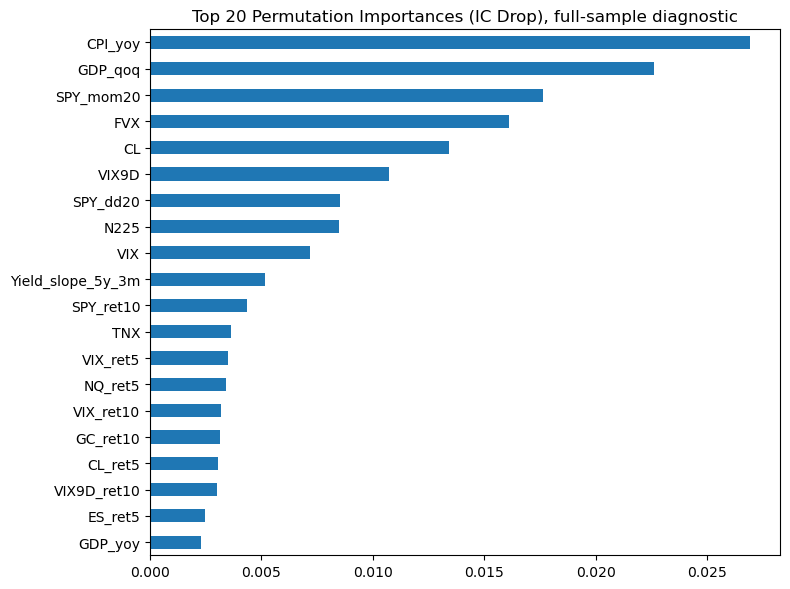

In [9]:
# ---- permutation importance (IC drop) ----
# DIAGNOSTIC ONLY: this ranking uses every test fold, so it is shown for
# interpretation and is NOT used to pick the features the models train on.
tscv = TimeSeriesSplit(n_splits=6, gap=GAP)
rng = np.random.default_rng(42)
ic_drops = {col: [] for col in X.columns}

for fold, (tr, te) in enumerate(tscv.split(X), 1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y.iloc[tr], y.iloc[te]

    Xtr, Xte, _ = align_drop_all_nan(Xtr, Xte)

    model = clone(models["HGBR"])
    model.fit(Xtr, ytr)

    base_pred = pd.Series(model.predict(Xte), index=Xte.index)
    base_ic = spearman_ic(yte, base_pred)
    if np.isnan(base_ic):
        continue

    for col in Xte.columns:
        Xp = Xte.copy()
        Xp[col] = permute_observed(Xp[col], rng)
        pp = pd.Series(model.predict(Xp), index=Xp.index)
        icp = spearman_ic(yte, pp)
        if not np.isnan(icp):
            ic_drops[col].append(base_ic - icp)

avg_drop = pd.Series({c: (np.mean(v) if len(v) else np.nan) for c, v in ic_drops.items()}).dropna()
avg_drop = avg_drop.sort_values(ascending=False)

print("Top 20 IC drivers (avg IC drop), full-sample diagnostic:")
display(avg_drop.head(20).to_frame("avg_ic_drop"))

# ---- pruned model: features re-selected inside each training fold ----
TOP_K = 25
tscv = TimeSeriesSplit(n_splits=6, gap=GAP)
pred_prun = pd.Series(index=X.index, dtype=float)
fold_features = []

for tr, te in tscv.split(X):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr = y.iloc[tr]
    feats = select_features(Xtr, ytr, top_k=TOP_K)       # training fold only
    fold_features.append(feats)
    Xtr, Xte, _ = align_drop_all_nan(Xtr[feats], Xte[feats])

    model = clone(models["HGBR"])
    model.fit(Xtr, ytr)
    pred_prun.iloc[te] = model.predict(Xte)

pred_prun = pred_prun.dropna()
yy_prun = y.loc[pred_prun.index]

print("\nIC comparison:")
print("Baseline (all feats) IC:", round(spearman_ic(yy_base, pred_base), 6))
print("Pruned   (fold-safe top feats) IC:", round(spearman_ic(yy_prun, pred_prun), 6))

# Plot top drivers
plt.figure(figsize=(8, 6))
avg_drop.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Permutation Importances (IC Drop), full-sample diagnostic")
plt.tight_layout()
plt.show()


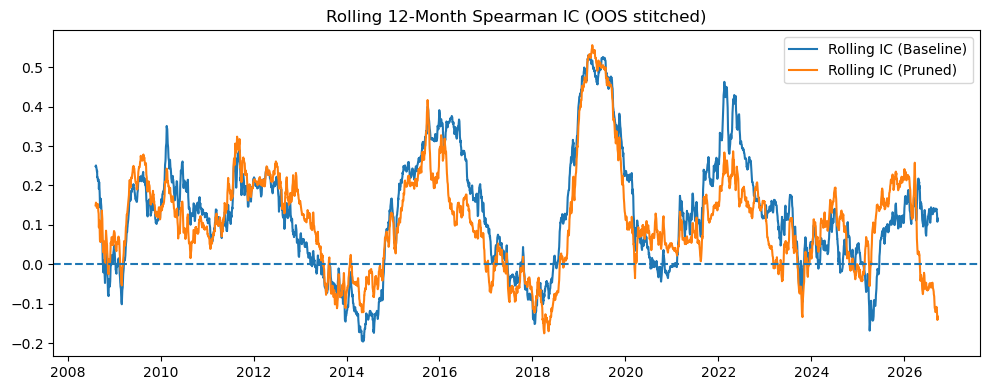

regime_high_vol: IC low=0.1051 | IC high=0.0706 | n=4836
regime_high_infl: IC low=0.1048 | IC high=0.0632 | n=4836
regime_high_growth: IC low=0.0948 | IC high=0.0494 | n=4836


In [10]:
def rolling_ic(y_true: pd.Series, y_pred: pd.Series, window=252, min_obs=126):
    s = pd.concat([y_true.rename("y"), y_pred.rename("p")], axis=1).dropna()
    out = pd.Series(index=s.index, dtype=float)
    for i in range(len(s)):
        w = s.iloc[max(0, i-window+1):i+1]
        if len(w) >= min_obs and w["y"].nunique() > 1 and w["p"].nunique() > 1:
            out.iloc[i] = spearman_ic(w["y"], w["p"])
        else:
            out.iloc[i] = np.nan
    return out

ric_base = rolling_ic(yy_base, pred_base)
ric_prun = rolling_ic(yy_prun, pred_prun)

plt.figure(figsize=(10,4))
plt.plot(ric_base.index, ric_base.values, label="Rolling IC (Baseline)")
plt.plot(ric_prun.index, ric_prun.values, label="Rolling IC (Pruned)")
plt.axhline(0, linestyle="--")
plt.title("Rolling 12-Month Spearman IC (OOS stitched)")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: IC by regime (if regime columns exist)
for reg in ["regime_high_vol","regime_high_infl","regime_high_growth"]:
    if reg in df_feat.columns:
        r = df_feat.loc[yy_base.index, reg].dropna()
        aligned = pd.concat([yy_base.rename("y"), pred_base.rename("p"), r.rename("r")], axis=1).dropna()
        if not aligned.empty:
            ic0 = spearman_ic(aligned.loc[aligned["r"]==0,"y"], aligned.loc[aligned["r"]==0,"p"])
            ic1 = spearman_ic(aligned.loc[aligned["r"]==1,"y"], aligned.loc[aligned["r"]==1,"p"])
            print(f"{reg}: IC low={ic0:.4f} | IC high={ic1:.4f} | n={len(aligned)}")


Overlay stats @ target_exposure=30% (threshold = 70th percentile)
Baseline: {'threshold': -0.0016, 'target_exposure': 0.3, 'tc_bps': 5.0, 'exposure': 0.3006, 'approx_sharpe': 0.5349, 'total_return': 2.1999}
Pruned:   {'threshold': 0.0024, 'target_exposure': 0.3, 'tc_bps': 5.0, 'exposure': 0.3006, 'approx_sharpe': 0.4907, 'total_return': 1.879}


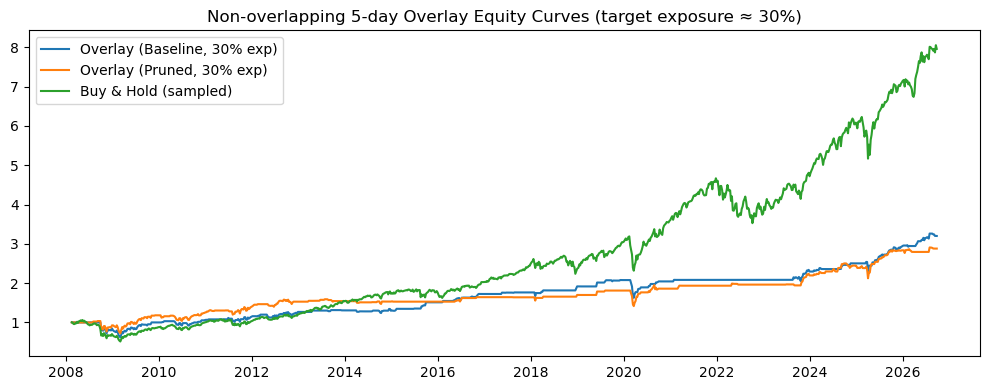

In [11]:
def overlay_backtest_nonoverlap(
    pred: pd.Series,
    y_true: pd.Series,
    step=5,
    threshold=None,           # <-- if None, we will auto-set it for target exposure
    tc_bps=5,
    target_exposure=0.30      # <-- NEW
):
    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().sort_index()
    decision = s.iloc[::step].copy()

    # --- NEW: choose threshold to hit target exposure (approximately) ---
    # For long-only rule pos = 1{pred > thr}, exposure ≈ fraction(pred > thr).
    # To get ~30% exposure, set thr to the 70th percentile of predictions at decision dates.
    if threshold is None:
        q = 1.0 - float(target_exposure)
        threshold = float(decision["pred"].quantile(q))

    decision["pos"] = (decision["pred"] > threshold).astype(float)

    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(decision["pos"].abs())
    decision["cost"] = decision["turnover"] * tc

    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]
    decision["eq_strat"] = (1 + decision["strat_ret"]).cumprod()
    decision["eq_buyhold"] = (1 + decision["y"]).cumprod()

    mean = float(decision["strat_ret"].mean())
    vol = float(decision["strat_ret"].std(ddof=0))
    sharpe = (mean / vol * np.sqrt(252/step)) if vol > 0 else np.nan

    stats = {
        "threshold": float(threshold),
        "target_exposure": float(target_exposure),
        "tc_bps": float(tc_bps),
        "exposure": float(decision["pos"].mean()),
        "approx_sharpe": float(sharpe),
        "total_return": float(decision["eq_strat"].iloc[-1] - 1.0)
    }
    return decision, stats


STEP = 5
TC_BPS = 5

# Target ~30% exposure (threshold auto-chosen from preds)
bt_base, st_base = overlay_backtest_nonoverlap(pred_base, yy_base, step=STEP, threshold=None, tc_bps=TC_BPS, target_exposure=0.30)
bt_prun, st_prun = overlay_backtest_nonoverlap(pred_prun, yy_prun, step=STEP, threshold=None, tc_bps=TC_BPS, target_exposure=0.30)

print("Overlay stats @ target_exposure=30% (threshold = 70th percentile)")
print("Baseline:", {k: round(v,4) for k,v in st_base.items()})
print("Pruned:  ", {k: round(v,4) for k,v in st_prun.items()})

plt.figure(figsize=(10,4))
plt.plot(bt_base.index, bt_base["eq_strat"], label="Overlay (Baseline, 30% exp)")
plt.plot(bt_prun.index, bt_prun["eq_strat"], label="Overlay (Pruned, 30% exp)")
plt.plot(bt_base.index, bt_base["eq_buyhold"], label="Buy & Hold (sampled)")
plt.title("Non-overlapping 5-day Overlay Equity Curves (target exposure ≈ 30%)")
plt.legend()
plt.tight_layout()
plt.show()

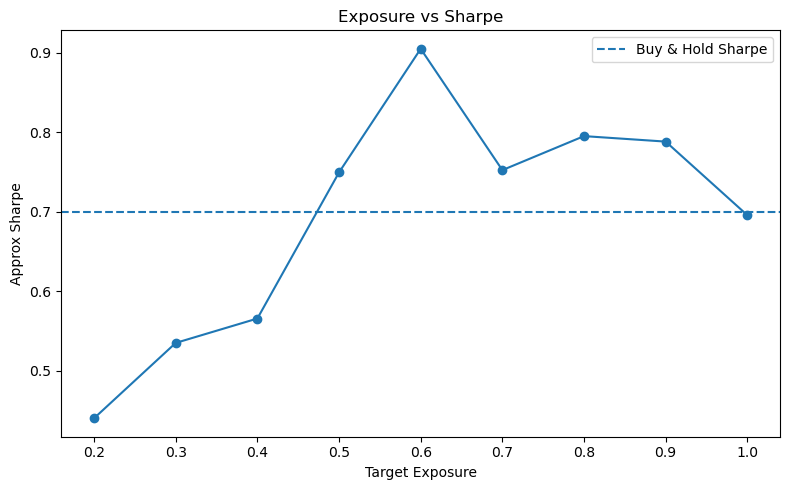

,target_exposure,realized_exposure,sharpe,total_return
0,0.2,0.200413,0.439986,1.378238
1,0.3,0.300620,0.534862,2.199861
2,0.4,0.399793,0.565592,2.613687
3,0.5,0.500000,0.749621,5.188782
4,0.6,0.600207,0.905271,8.964603
5,0.7,0.699380,0.752490,6.140046
6,0.8,0.799587,0.795316,7.580861
7,0.9,0.899793,0.788402,8.449797
8,1.0,0.998967,0.695717,6.836922


In [12]:
# Choose which signal to evaluate
pred = pred_base      # or pred_prun
y_true = yy_base      # or yy_prun

STEP = 5
TC_BPS = 5

# Exposure levels to test
exposure_grid = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

rows = []

for exp in exposure_grid:
    bt, stats = overlay_backtest_nonoverlap(
        pred=pred,
        y_true=y_true,
        step=STEP,
        threshold=None,           # auto-calculated from exposure
        tc_bps=TC_BPS,
        target_exposure=exp
    )
    rows.append({
        "target_exposure": exp,
        "realized_exposure": stats["exposure"],
        "sharpe": stats["approx_sharpe"],
        "total_return": stats["total_return"]
    })

res = pd.DataFrame(rows)

# --- Buy & Hold Sharpe (for comparison) ---
bh = pd.DataFrame({"y": y_true}).dropna()
bh_decision = bh.iloc[::STEP]
mean_bh = bh_decision["y"].mean()
vol_bh = bh_decision["y"].std(ddof=0)
sharpe_bh = (mean_bh / vol_bh) * np.sqrt(252/STEP)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(res["target_exposure"], res["sharpe"], marker="o")
plt.axhline(sharpe_bh, linestyle="--", label="Buy & Hold Sharpe")
plt.xlabel("Target Exposure")
plt.ylabel("Approx Sharpe")
plt.title("Exposure vs Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

display(res)

=== Long/Short 30/30 Results ===
{'long_quantile': 0.7, 'short_quantile': 0.3, 'long_exposure': np.float64(0.3006), 'short_exposure': np.float64(0.3006), 'approx_sharpe': 0.373, 'total_return': 1.4401}


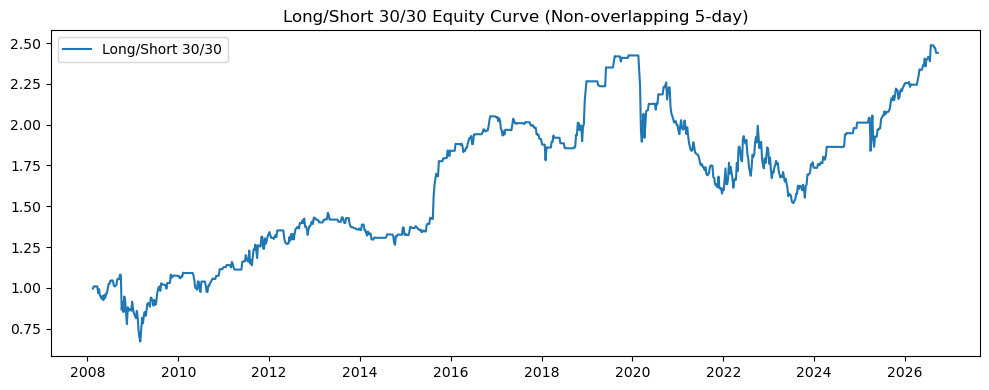

In [13]:
def overlay_long_short_nonoverlap(
    pred: pd.Series,
    y_true: pd.Series,
    step=5,
    long_quantile=0.70,
    short_quantile=0.30,
    tc_bps=5
):
    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().sort_index()
    decision = s.iloc[::step].copy()

    # Determine thresholds
    long_thr = decision["pred"].quantile(long_quantile)
    short_thr = decision["pred"].quantile(short_quantile)

    # Position logic
    decision["pos"] = 0
    decision.loc[decision["pred"] >= long_thr, "pos"] = 1
    decision.loc[decision["pred"] <= short_thr, "pos"] = -1

    # Transaction cost
    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(abs(decision["pos"]))
    decision["cost"] = decision["turnover"] * tc

    # Strategy returns
    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]
    decision["eq_strat"] = (1 + decision["strat_ret"]).cumprod()

    # Metrics
    mean = decision["strat_ret"].mean()
    vol = decision["strat_ret"].std(ddof=0)
    sharpe = (mean / vol) * np.sqrt(252/step) if vol > 0 else np.nan

    stats = {
        "long_quantile": long_quantile,
        "short_quantile": short_quantile,
        "long_exposure": (decision["pos"] == 1).mean(),
        "short_exposure": (decision["pos"] == -1).mean(),
        "approx_sharpe": float(sharpe),
        "total_return": float(decision["eq_strat"].iloc[-1] - 1.0)
    }

    return decision, stats


# ---- Run it ----
STEP = 5
TC_BPS = 5

bt_ls, st_ls = overlay_long_short_nonoverlap(
    pred=pred_base,
    y_true=yy_base,
    step=STEP,
    long_quantile=0.70,
    short_quantile=0.30,
    tc_bps=TC_BPS
)

print("=== Long/Short 30/30 Results ===")
print({k: round(v,4) if isinstance(v, float) else v for k,v in st_ls.items()})

plt.figure(figsize=(10,4))
plt.plot(bt_ls.index, bt_ls["eq_strat"], label="Long/Short 30/30")
plt.title("Long/Short 30/30 Equity Curve (Non-overlapping 5-day)")
plt.legend()
plt.tight_layout()
plt.show()


,model,rule,threshold,target_exposure,tc_bps,exposure,approx_sharpe,total_return
1,Baseline,mean,-0.014386,0.3,5.0,0.649793,0.824857,7.348446
2,Baseline,q50,-0.008961,0.3,5.0,0.490702,0.697467,4.341127
3,Baseline,q55,-0.007075,0.3,5.0,0.452479,0.633612,3.411735
4,Baseline,q60,-0.005263,0.3,5.0,0.411157,0.621405,3.203665
5,Baseline,q65,-0.003456,0.3,5.0,0.352273,0.575427,2.643235
6,Baseline,q70,-0.001484,0.3,5.0,0.295455,0.534263,2.188577
7,Baseline,q75,-0.000114,0.3,5.0,0.247934,0.504057,1.848888
0,Baseline,zero,0.000000,0.3,5.0,0.244835,0.488770,1.745618
8,Baseline,q80,0.001611,0.3,5.0,0.196281,0.420522,1.272521
10,Pruned,mean,-0.006090,0.3,5.0,0.535124,0.822758,6.916958


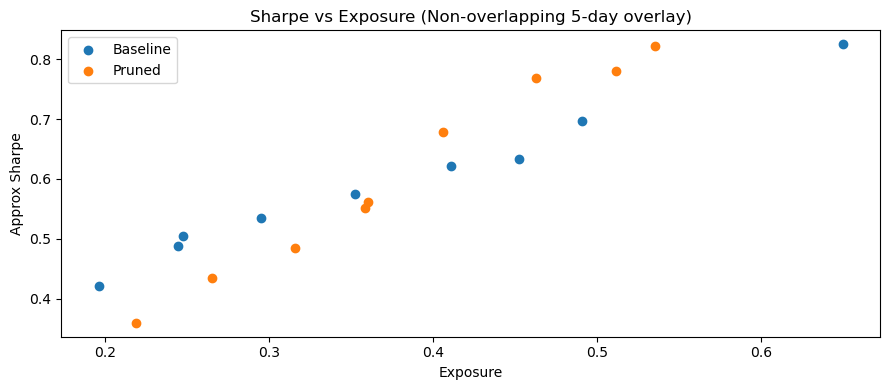

In [14]:
def threshold_grid(pred: pd.Series):
    qs = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
    q_vals = {f"q{int(q*100)}": float(pred.quantile(q)) for q in qs}
    return {"zero": 0.0, "mean": float(pred.mean()), **q_vals}

grid_base = threshold_grid(pred_base)
grid_prun = threshold_grid(pred_prun)

rows = []
for label, thr in grid_base.items():
    _, st = overlay_backtest_nonoverlap(pred_base, yy_base, step=STEP, threshold=thr, tc_bps=TC_BPS)
    rows.append({"model":"Baseline","rule":label, **st})

for label, thr in grid_prun.items():
    _, st = overlay_backtest_nonoverlap(pred_prun, yy_prun, step=STEP, threshold=thr, tc_bps=TC_BPS)
    rows.append({"model":"Pruned","rule":label, **st})

res = pd.DataFrame(rows).sort_values(["model","approx_sharpe"], ascending=[True, False])
display(res)

plt.figure(figsize=(9,4))
for m in ["Baseline","Pruned"]:
    sub = res[res["model"]==m]
    plt.scatter(sub["exposure"], sub["approx_sharpe"], label=m)
plt.xlabel("Exposure")
plt.ylabel("Approx Sharpe")
plt.title("Sharpe vs Exposure (Non-overlapping 5-day overlay)")
plt.legend()
plt.tight_layout()
plt.show()


{'Sharpe': 1.1143675303220097, 'AvgExposure': 0.6123759410721566, 'TotalReturn': 8.864926038828033}


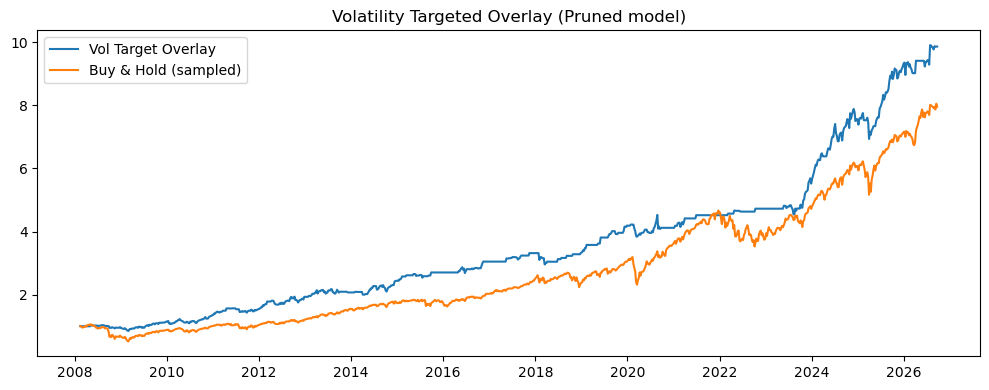

In [15]:
TARGET_VOL_ANNUAL = 0.15

def vol_target_overlay(pred, y_true, step=5, tc_bps=5, target_vol_annual=0.15):
    s = pd.DataFrame({"pred": pred, "y": y_true}).dropna().sort_index()
    decision = s.iloc[::step].copy()

    thr = float(pred.mean())
    decision["signal"] = (decision["pred"] > thr).astype(float)

    # Volatility known at the decision date (daily returns up to that close).
    # (Previously this used the rolling std of forward 5-day returns, which
    #  includes future prices.)
    ann_vol = ANN_VOL.reindex(decision.index)

    decision["pos"] = decision["signal"] * (target_vol_annual / ann_vol)
    decision["pos"] = decision["pos"].clip(upper=2.0).fillna(0.0)

    tc = tc_bps / 10000.0
    decision["turnover"] = decision["pos"].diff().abs().fillna(decision["pos"].abs())
    decision["cost"] = decision["turnover"] * tc

    decision["strat_ret"] = decision["pos"] * decision["y"] - decision["cost"]
    decision["eq"] = (1 + decision["strat_ret"]).cumprod()
    decision["eq_buyhold"] = (1 + decision["y"]).cumprod()

    mean = decision["strat_ret"].mean()
    vol = decision["strat_ret"].std(ddof=0)
    sharpe = mean / vol * np.sqrt(252/step) if vol > 0 else np.nan

    return decision, {"Sharpe": float(sharpe), "AvgExposure": float(decision["pos"].mean()),
                      "TotalReturn": float(decision["eq"].iloc[-1]-1)}

bt_vol, st_vol = vol_target_overlay(pred_prun, yy_prun, step=STEP, tc_bps=TC_BPS, target_vol_annual=TARGET_VOL_ANNUAL)
print(st_vol)

plt.figure(figsize=(10,4))
plt.plot(bt_vol.index, bt_vol["eq"], label="Vol Target Overlay")
plt.plot(bt_vol.index, bt_vol["eq_buyhold"], label="Buy & Hold (sampled)")
plt.title("Volatility Targeted Overlay (Pruned model)")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# ============================================================
# Expanding Window Retrain (Production-Style)
#   - Retrains every 5 days on all data available at that point
#   - Purge gap: drops the last GAP training rows whose 5-day targets
#     overlap the test block
#   - Features re-selected about once a year using ONLY the training data
#     available at that time (no look-ahead in feature choice)
#   - The resulting feature schedule is reused by the model comparison below
# ============================================================

MIN_TRAIN = 756        # ~3 years of daily data
STEP = 5
RESELECT_EVERY = 252   # re-run feature selection roughly once a year

pred_expanding = pd.Series(index=X.index, dtype=float)
feature_schedule = {}
current_feats, last_sel = None, None

for start in range(MIN_TRAIN, len(X) - STEP + 1, STEP):
    train_end = start - GAP

    if current_feats is None or start - last_sel >= RESELECT_EVERY:
        current_feats = select_features(X.iloc[:train_end], y.iloc[:train_end], top_k=TOP_K)
        last_sel = start
    feature_schedule[start] = current_feats

    X_train = X.iloc[:train_end][current_feats].copy()
    y_train = y.iloc[:train_end]
    X_test  = X.iloc[start:start+STEP][current_feats].copy()

    X_train2, X_test2, _ = align_drop_all_nan(X_train, X_test)

    model = clone(models["HGBR"])
    model.fit(X_train2, y_train)
    pred_expanding.iloc[start:start+STEP] = model.predict(X_test2)

pred_expanding = pred_expanding.dropna()
y_exp = y.loc[pred_expanding.index]

ic_expanding = spearman_ic(y_exp, pred_expanding)
n_sel = len({tuple(v) for v in feature_schedule.values()})
print(f"Feature re-selections: {n_sel} distinct feature sets over {len(feature_schedule)} retrains")
sel_counts = pd.Series([f for v in {k: v for k, v in feature_schedule.items()}.values() for f in v]).value_counts()
print("Most frequently selected features (share of retrains):")
print((sel_counts / len(feature_schedule)).head(10).round(2).to_string())
print(f"\nExpanding Window OOS IC: {ic_expanding:.6f}")


Feature re-selections: 20 distinct feature sets over 978 retrains
Most frequently selected features (share of retrains):
VIX_ret5     1.00
CPI_yoy      1.00
DJI          0.90
SPY_mom20    0.90
SPY_dd20     0.79
NQ_ret5      0.74
GDP_yoy      0.74
GC_ret10     0.74
TNX          0.69
MSCI         0.69

Expanding Window OOS IC: 0.006043


In [17]:
# ============================================================
# MLP Regression (NaN-safe, production style)
# ============================================================


pipe_mlp = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # FIX
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

tscv = TimeSeriesSplit(n_splits=6, gap=GAP)

pred_oos = pd.Series(index=X.index, dtype=float)

for tr, te in tscv.split(X):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr = y.iloc[tr]

    pipe_mlp.fit(Xtr, ytr)
    pred_oos.iloc[te] = pipe_mlp.predict(Xte)

pred_oos = pred_oos.dropna()
y_oos = y.loc[pred_oos.index]

def spearman_ic(a, b):
    return a.rank(pct=True).corr(b.rank(pct=True))

ic_mlp = spearman_ic(y_oos, pred_oos)

print(f"MLP Stitched OOS IC: {ic_mlp:.6f}")

MLP Stitched OOS IC: 0.035103


In [18]:
print("HGBR stitched OOS IC:", round(spearman_ic(yy_base, pred_base), 6))
print("MLP stitched OOS IC: ", round(ic_mlp, 6))


HGBR stitched OOS IC: 0.087838
MLP stitched OOS IC:  0.035103


Samples used (expanding OOS): 4890 | Features: 25 per retrain (re-selected ~annually from past data)

=== Expanding Window OOS IC (higher is better) ===
Ridge    0.032517
HGBR     0.006043
MLP     -0.001454


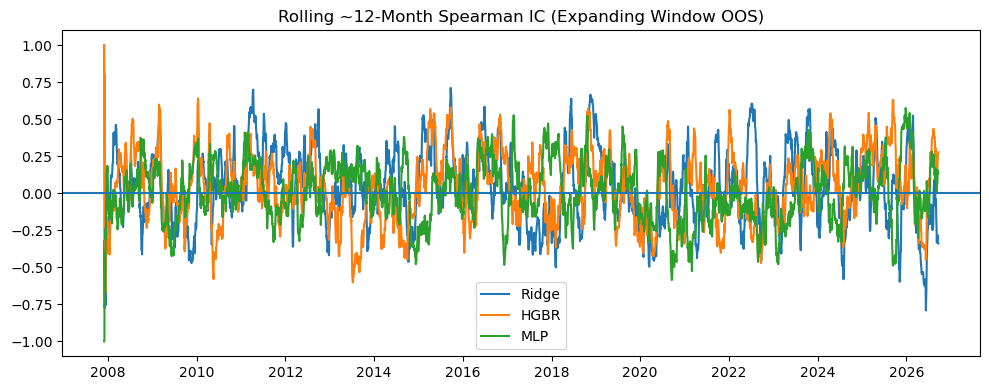


=== Interpretation ===
Best expanding IC model: Ridge (IC=0.0325)
Runner-up: HGBR (IC=0.0060)

MLP - HGBR IC delta: -0.0075
➖ Likely similar: MLP does not materially add signal vs HGBR; choose based on stability/overlay performance.

Next step suggestion:
1) Run your overlay + vol-target backtest using each model's expanding preds (same threshold rule),
2) Compare Sharpe/exposure/drawdown. If MLP doesn't improve Sharpe, keep HGBR as primary and cite MLP as robustness.


In [19]:
# ============================================================
# Model Comparison (Ridge vs HGBR vs MLP)
# - Expanding-window predictions (production-style)
# - Expanding OOS IC
# - Rolling 12M IC plot (all models)
# - Quick interpretation helpers
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

# -----------------------------
# Preconditions
# -----------------------------
assert "X" in globals() and "y" in globals(), "Need X and y in memory."
assert isinstance(X, pd.DataFrame) and isinstance(y, (pd.Series, pd.DataFrame)), "X must be DataFrame and y must be Series."
if isinstance(y, pd.DataFrame):
    # If y is a single-column DF, convert to Series
    if y.shape[1] == 1:
        y = y.iloc[:, 0]
    else:
        raise ValueError("y is a DataFrame with multiple columns; please pass a Series target.")

# Full feature matrix; each retrain uses the features chosen for that date in
# feature_schedule (built from past data only in the expanding-window cell).
X_use = X.copy()
assert "feature_schedule" in globals(), "Run the expanding-window cell first."

# -----------------------------
# Utility: Spearman IC (no scipy)
# -----------------------------
def spearman_ic(y_true, y_pred) -> float:
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    if y_true.nunique(dropna=True) < 2 or y_pred.nunique(dropna=True) < 2:
        return np.nan
    return float(y_true.rank(pct=True).corr(y_pred.rank(pct=True)))

# -----------------------------
# Define 3 models (pipelines)
# -----------------------------
pipe_ridge = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=42))
])

pipe_hgbr = globals().get("models", {}).get("HGBR", None)
if pipe_hgbr is None:
    # fallback if you don't have models["HGBR"] available
    from sklearn.ensemble import HistGradientBoostingRegressor
    pipe_hgbr = Pipeline([
        ("imp", SimpleImputer(strategy="median")),  # safe even though HGBR can handle NaNs
        ("hgbr", HistGradientBoostingRegressor(
            max_depth=3, learning_rate=0.05, max_iter=400, random_state=42
        ))
    ])

pipe_mlp = Pipeline([
    ("imp", SimpleImputer(strategy="median")),  # MLP needs this
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=600,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    ))
])

MODELS = {
    "Ridge": pipe_ridge,
    "HGBR": pipe_hgbr,
    "MLP":  pipe_mlp
}

# -----------------------------
# Expanding-window prediction runner
# -----------------------------
def expanding_preds(X_in: pd.DataFrame, y_in: pd.Series, model, min_train=756, step=5,
                    gap=GAP, schedule=None):
    preds = pd.Series(index=X_in.index, dtype=float)
    for start in range(min_train, len(X_in) - step, step):
        feats = schedule[start] if schedule is not None else list(X_in.columns)
        Xtr = X_in.iloc[:start - gap][feats]      # purge gap
        ytr = y_in.iloc[:start - gap]
        Xte = X_in.iloc[start:start+step][feats]
        Xtr, Xte, _ = align_drop_all_nan(Xtr, Xte)

        m = clone(model)
        m.fit(Xtr, ytr)
        preds.iloc[start:start+step] = m.predict(Xte)
    preds = preds.dropna()
    y_al = y_in.loc[preds.index]
    return preds, y_al

MIN_TRAIN = 756
STEP = 5

preds_dict = {}
ic_dict = {}

for name, model in MODELS.items():
    p, y_al = expanding_preds(X_use, y, model, min_train=MIN_TRAIN, step=STEP, schedule=feature_schedule)
    preds_dict[name] = p
    ic_dict[name] = spearman_ic(y_al, p)

# -----------------------------
# Print Expanding IC comparison
# -----------------------------
ic_table = pd.Series(ic_dict).sort_values(ascending=False)
print(f"Samples used (expanding OOS): {len(next(iter(preds_dict.values())))} | Features: {TOP_K} per retrain (re-selected ~annually from past data)")
print("\n=== Expanding Window OOS IC (higher is better) ===")
print(ic_table.round(6).to_string())

# -----------------------------
# Rolling 12-month IC for each model (on expanding OOS)
# Note: With non-overlapping 5-day steps, 12 months ≈ 252/5 ≈ 50 observations.
# We'll use a window of 52 (about 1 year of weekly-ish observations).
# -----------------------------
ROLL_WIN = 52

rolling_ic = pd.DataFrame(index=preds_dict[ic_table.index[0]].index)

for name, p in preds_dict.items():
    y_al = y.loc[p.index]
    rolling_ic[name] = (
        pd.Series(
            [spearman_ic(y_al.iloc[max(0, i-ROLL_WIN+1):i+1],
                         p.iloc[max(0, i-ROLL_WIN+1):i+1])
             for i in range(len(p))],
            index=p.index
        )
    )

# Align all to common index (intersection)
common_idx = rolling_ic.dropna(how="all").index
rolling_ic = rolling_ic.loc[common_idx]

# Plot rolling IC comparison
plt.figure(figsize=(10,4))
for col in rolling_ic.columns:
    plt.plot(rolling_ic.index, rolling_ic[col].values, label=col)
plt.axhline(0)
plt.title("Rolling ~12-Month Spearman IC (Expanding Window OOS)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Quick interpretation helpers
# -----------------------------
best = ic_table.index[0]
second = ic_table.index[1] if len(ic_table) > 1 else None

print("\n=== Interpretation ===")
print(f"Best expanding IC model: {best} (IC={ic_table.iloc[0]:.4f})")
if second:
    print(f"Runner-up: {second} (IC={ic_table.iloc[1]:.4f})")

# Does MLP add signal? Compare to HGBR
if "MLP" in ic_table.index and "HGBR" in ic_table.index:
    delta = ic_table["MLP"] - ic_table["HGBR"]
    print(f"\nMLP - HGBR IC delta: {delta:+.4f}")
    if delta > 0.01:
        print("✅ Likely meaningful: MLP appears to add incremental signal vs HGBR (check overlay Sharpe next).")
    elif delta > -0.01:
        print("➖ Likely similar: MLP does not materially add signal vs HGBR; choose based on stability/overlay performance.")
    else:
        print("⚠ Likely worse: MLP underperforms HGBR on expanding IC; treat as a robustness check rather than a superior model.")

print("\nNext step suggestion:")
print("1) Run your overlay + vol-target backtest using each model's expanding preds (same threshold rule),")
print("2) Compare Sharpe/exposure/drawdown. If MLP doesn't improve Sharpe, keep HGBR as primary and cite MLP as robustness.")

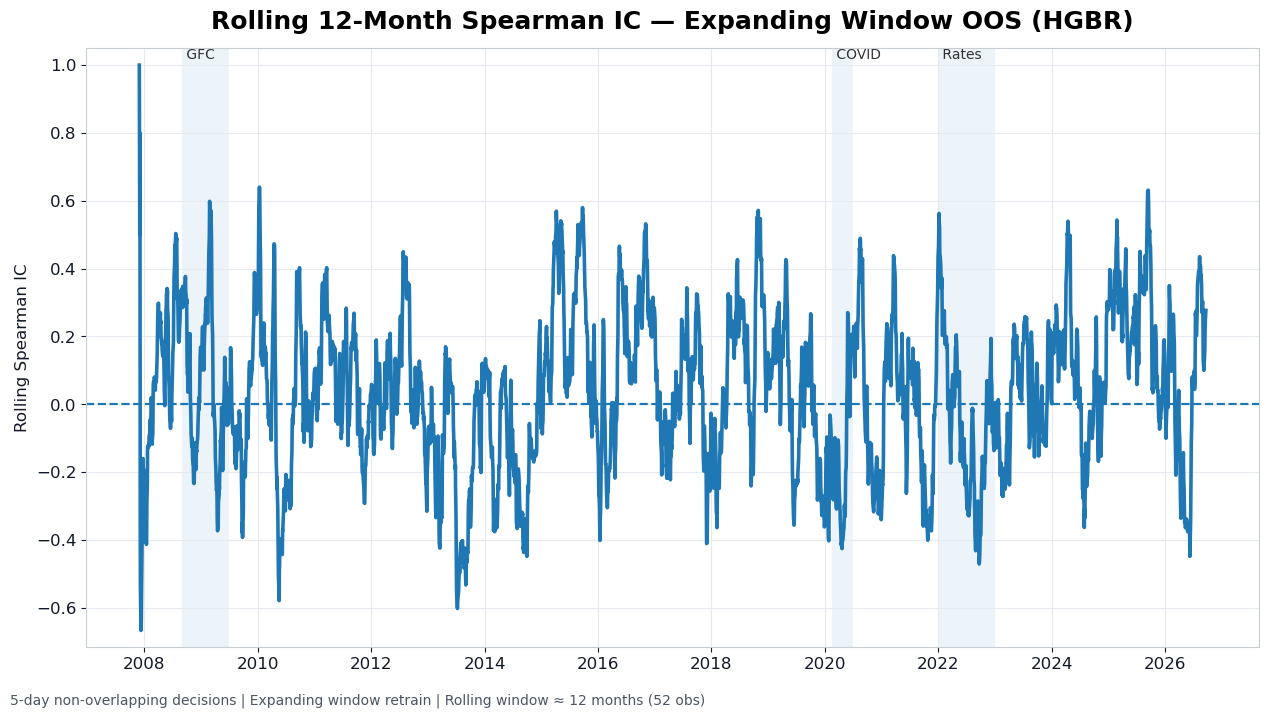

Saved: rolling_ic_hgbr_expanding_institutional.png
Rolling IC summary: count    4889.0000
mean        0.0366
std         0.2281
min        -0.6667
25%        -0.1216
50%         0.0412
75%         0.1943
max         1.0000


In [20]:
# ============================================================
# Institutional Rolling 12M IC Chart (HGBR, Expanding Window OOS)
# Robust auto-detection of your expanding predictions
# Saves: rolling_ic_hgbr_expanding_institutional.png (in current folder)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Spearman IC (no scipy) ----
def spearman_ic(a, b) -> float:
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    m = a.notna() & b.notna()
    if m.sum() < 3:
        return np.nan
    ar = a[m].rank(pct=True)
    br = b[m].rank(pct=True)
    if ar.nunique() < 2 or br.nunique() < 2:
        return np.nan
    return float(ar.corr(br))

# ============================================================
# 1) FIND EXPANDING HGBR PREDICTIONS + ALIGNED TARGET
# ============================================================
p = None          # expanding OOS preds for HGBR
y_al = None       # aligned y at p.index

# Common pattern from your "Model Comparison" cell:
# preds_dict is a dict like {"Ridge": series, "HGBR": series, "MLP": series}
if p is None and "preds_dict" in globals():
    try:
        if isinstance(preds_dict, dict) and "HGBR" in preds_dict:
            p = pd.Series(preds_dict["HGBR"]).dropna()
            y_al = pd.Series(y).loc[p.index]
    except Exception:
        pass

# If you computed rolling_ic DataFrame already (multi-model rolling IC)
rolling_ic_series = None
if rolling_ic_series is None and "rolling_ic" in globals():
    try:
        if isinstance(rolling_ic, pd.DataFrame) and "HGBR" in rolling_ic.columns:
            rolling_ic_series = rolling_ic["HGBR"].dropna()
    except Exception:
        pass

# Other common names you may have used
if p is None and "pred_expanding_hgbr" in globals():
    p = pd.Series(pred_expanding_hgbr).dropna()
    y_al = pd.Series(y).loc[p.index]

if p is None and "pred_expanding" in globals():
    # some notebooks store HGBR expanding preds simply as pred_expanding
    p = pd.Series(pred_expanding).dropna()
    y_al = pd.Series(y).loc[p.index]

# Safety check
if rolling_ic_series is None and (p is None or y_al is None):
    # Show user what we see without asking questions
    candidates = [k for k in globals().keys() if "pred" in k.lower() or "rolling" in k.lower()]
    raise ValueError(
        "Could not auto-detect expanding HGBR predictions.\n\n"
        "Expected one of:\n"
        "  - preds_dict['HGBR']\n"
        "  - pred_expanding_hgbr\n"
        "  - pred_expanding\n"
        "  - rolling_ic DataFrame with column 'HGBR'\n\n"
        f"Found candidate variable names:\n{candidates[:40]}"
    )

# ============================================================
# 2) BUILD ROLLING ~12M IC IF NOT ALREADY PROVIDED
# ============================================================
ROLL_WIN = 52  # ~12 months for 5-day cadence (≈252/5)

if rolling_ic_series is None:
    # compute rolling IC from (y_al, p)
    vals = np.empty(len(p))
    vals[:] = np.nan
    for i in range(len(p)):
        lo = max(0, i - ROLL_WIN + 1)
        vals[i] = spearman_ic(y_al.iloc[lo:i+1], p.iloc[lo:i+1])
    rolling_ic_series = pd.Series(vals, index=p.index).dropna()

# ============================================================
# 3) INSTITUTIONAL STYLING + PLOT
# ============================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#C7CDD3",
    "axes.labelcolor": "#111827",
    "xtick.color": "#111827",
    "ytick.color": "#111827",
    "grid.color": "#E6E9EF",
    "grid.linewidth": 0.8,
    "font.size": 12,
})

fig = plt.figure(figsize=(12.8, 7.2))  # 16:9 slide-friendly
ax = plt.gca()

ax.plot(rolling_ic_series.index, rolling_ic_series.values, linewidth=2.6)
ax.axhline(0, linewidth=1.6, linestyle="--")
ax.grid(True, which="major", axis="both")

ax.set_title("Rolling 12-Month Spearman IC — Expanding Window OOS (HGBR)",
             pad=14, fontsize=18, fontweight="bold")
ax.set_ylabel("Rolling Spearman IC")
ax.set_xlabel("")

# Nice y-limits
ymin = float(np.nanmin(rolling_ic_series.values))
ymax = float(np.nanmax(rolling_ic_series.values))
pad = 0.05
ax.set_ylim(ymin - pad, ymax + pad)

# Optional: light regime shading
ADD_SHADE = True
if ADD_SHADE:
    def shade(start, end, label=None):
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.08)
        if label:
            ax.text(pd.to_datetime(start), ax.get_ylim()[1], f" {label}",
                    va="top", fontsize=10, alpha=0.8)
    shade("2008-09-01", "2009-06-30", "GFC")
    shade("2020-02-15", "2020-06-30", "COVID")
    shade("2022-01-01", "2022-12-31", "Rates")

# Footnote
foot = "5-day non-overlapping decisions | Expanding window retrain | Rolling window ≈ 12 months (52 obs)"
fig.text(0.01, 0.01, foot, fontsize=10, color="#4B5563")

plt.tight_layout(rect=(0, 0.03, 1, 1))

# Save locally (works on your machine)
out_path = "rolling_ic_hgbr_expanding_institutional.png"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
print("Rolling IC summary:", rolling_ic_series.describe().round(4).to_string())

=== Summary (Overlay + Vol-Target + Buy&Hold) ===
         best_rule       thr  overlay_sharpe  overlay_total  overlay_max_dd  overlay_exposure  overlay_pct_pos  vt_sharpe  vt_total  vt_max_dd  vt_avg_lev  vt_avg_exposure  vt_pct_pos  buyhold_total  buyhold_max_dd
model                                                                                                                                                                                                                 
Ensemble       q55  0.001251        0.427841       1.315142       -0.400498          0.449898         0.273006   0.674115  1.551417  -0.112042    0.831389         0.449898    0.273006       6.434877       -0.535447
HGBR          mean -0.000187        0.466460       1.656840       -0.408999          0.537832         0.324131   0.635162  1.590328  -0.168772    0.831389         0.537832    0.323108       6.434877       -0.535447


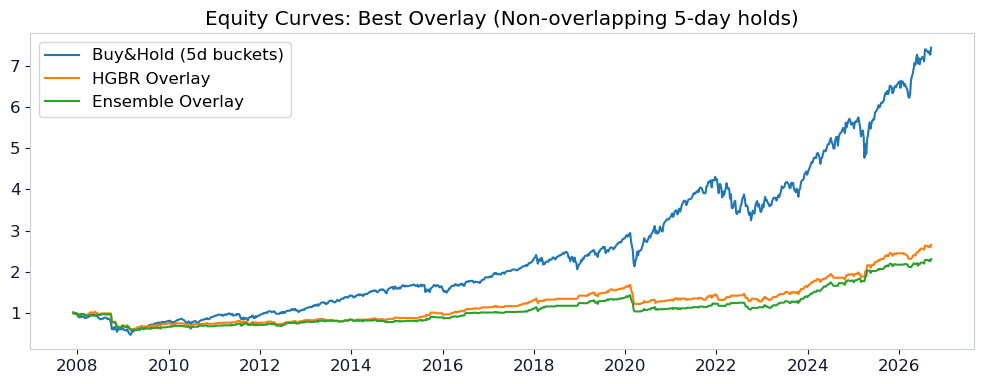

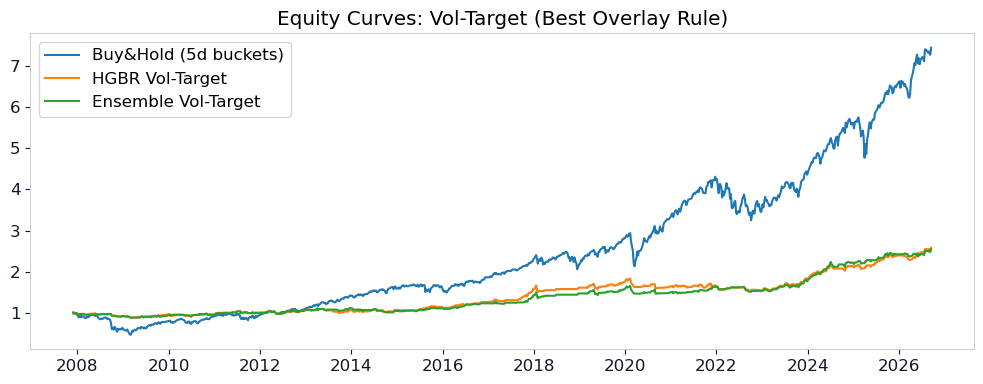

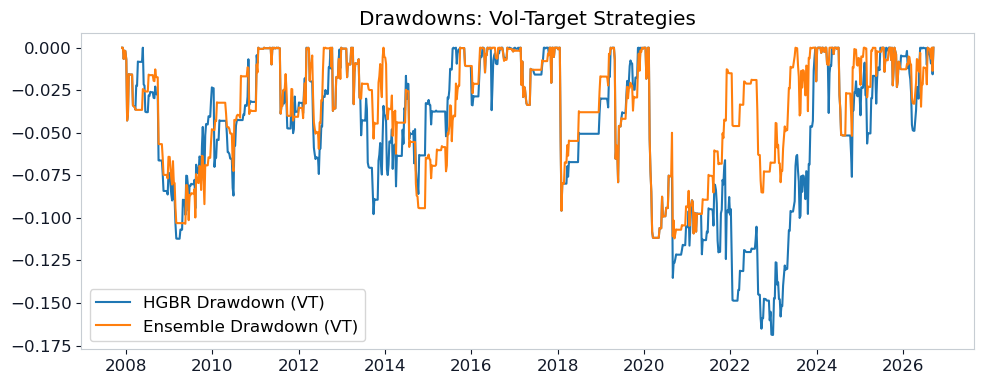

In [21]:
# ============================================================
# NEXT CELL: Overlay + Vol-Target + Drawdowns + Ensemble
# - Uses expanding-window preds from your prior comparison cell: preds_dict
# - Runs:
#   (1) HGBR overlay + vol-target
#   (2) Compare Sharpe / Max DD / Exposure / Stability vs Buy&Hold
#   (3) Optional ensemble: 0.7*HGBR + 0.3*Ridge
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Preconditions
# -----------------------------
assert "preds_dict" in globals(), "Run the model comparison cell first (needs preds_dict)."
assert "y" in globals(), "Need y (5-day forward return series)."
assert "X_use" in globals(), "Need X_use (feature index)."
assert "df" in globals() and "SPY" in df.columns, "Need df with SPY price series."

# -----------------------------
# Config
# -----------------------------
STEP = 5                 # non-overlapping 5-day holds
TC_BPS = 5.0             # transaction cost per position change (bps)
ROLL_VOL = 20            # daily vol lookback for vol targeting
TARGET_VOL = 0.10        # 10% annual vol target
MAX_LEV = 2.0            # leverage cap
RULES = ["mean", "q50", "q55", "q60", "q65", "q70", "q75", "q80", "zero"]

spy_px = df["SPY"].astype(float)
full_index = X_use.index

# -----------------------------
# Helpers
# -----------------------------
def max_drawdown(eq: pd.Series) -> float:
    eq = eq.dropna()
    if len(eq) == 0:
        return np.nan
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return float(dd.min())

def decision_dates_from_preds(preds: pd.Series, full_index: pd.Index, step: int) -> pd.Index:
    first = preds.index[0]
    first_pos = full_index.get_loc(first)
    dec_pos = np.arange(first_pos, len(full_index) - step, step)
    return full_index[dec_pos]

def overlay_backtest(preds: pd.Series, y5: pd.Series, full_index: pd.Index,
                     rule: str, step: int = 5, tc_bps: float = 5.0):
    dec_dates = decision_dates_from_preds(preds, full_index, step)
    dec_dates = dec_dates.intersection(preds.index).intersection(y5.index)

    p_dec = preds.loc[dec_dates].copy()

    if rule == "zero":
        thr = 0.0
    elif rule == "mean":
        thr = float(p_dec.mean())
    elif rule.startswith("q"):
        thr = float(p_dec.quantile(float(rule[1:]) / 100.0))
    else:
        raise ValueError("Unknown rule")

    pos = (p_dec > thr).astype(float)
    r = y5.loc[dec_dates].astype(float)

    turn = pos.diff().abs().fillna(pos.iloc[0])
    tc = (tc_bps / 10000.0) * turn
    r_net = pos * r - tc
    eq = (1.0 + r_net).cumprod()

    out = pd.DataFrame({
        "pred": p_dec,
        "pos": pos,
        "ret5": r,
        "turn": turn,
        "tc": tc,
        "ret5_net": r_net,
        "eq": eq
    }, index=dec_dates)

    mean_r = out["ret5_net"].mean()
    vol_r  = out["ret5_net"].std(ddof=0)
    sharpe = np.nan if vol_r == 0 else (mean_r / vol_r) * np.sqrt(252 / step)

    stats = {
        "rule": rule,
        "threshold": thr,
        "approx_sharpe": float(sharpe),
        "total_return": float(eq.iloc[-1] - 1.0) if len(eq) else np.nan,
        "max_dd": max_drawdown(eq),
        "exposure": float(out["pos"].mean()) if len(out) else np.nan,
        "n_periods": int(len(out)),
        "n_trades": int(out["turn"].sum()) if len(out) else 0,
        "mean_ret_per_period": float(mean_r),
        "vol_ret_per_period": float(vol_r),
    }
    return out, stats

def vol_target_backtest(overlay_df: pd.DataFrame, spy_px: pd.Series,
                        target_vol=0.10, max_lev=2.0, roll=20, step=5, tc_bps=5.0):
    # daily realized vol known at each decision date (see ANN_VOL)
    ann_vol = ANN_VOL.reindex(overlay_df.index)

    lev = (target_vol / ann_vol).clip(lower=0.0, upper=max_lev).fillna(0.0)
    w = overlay_df["pos"] * lev

    turn_w = w.diff().abs().fillna(w.iloc[0])
    tc = (tc_bps / 10000.0) * turn_w

    r = overlay_df["ret5"]
    r_net = w * r - tc
    eq = (1.0 + r_net).cumprod()

    out = overlay_df.copy()
    out["ann_vol"] = ann_vol
    out["lev"] = lev
    out["w"] = w
    out["tc_vt"] = tc
    out["ret5_net_vt"] = r_net
    out["eq_vt"] = eq

    mean_r = out["ret5_net_vt"].mean()
    vol_r  = out["ret5_net_vt"].std(ddof=0)
    sharpe = np.nan if vol_r == 0 else (mean_r / vol_r) * np.sqrt(252 / step)

    stats = {
        "approx_sharpe": float(sharpe),
        "total_return": float(eq.iloc[-1] - 1.0) if len(eq) else np.nan,
        "max_dd": max_drawdown(eq),
        "avg_lev": float(lev.mean()),
        "avg_exposure": float((w > 0).mean()),
    }
    return out, stats

def stability_metrics(ret_series: pd.Series) -> dict:
    """
    Stability proxies for 5-day strategy returns:
    - pct_positive: fraction of periods positive
    - worst_period: min 5d net return
    - best_period: max 5d net return
    """
    r = ret_series.dropna()
    if len(r) == 0:
        return {"pct_positive": np.nan, "worst_period": np.nan, "best_period": np.nan}
    return {
        "pct_positive": float((r > 0).mean()),
        "worst_period": float(r.min()),
        "best_period": float(r.max()),
    }

# -----------------------------
# Step 0: Build Ensemble preds
# -----------------------------
assert "HGBR" in preds_dict and "Ridge" in preds_dict, "Need preds_dict['HGBR'] and preds_dict['Ridge']."
p_hgbr = preds_dict["HGBR"].dropna()
p_ridge = preds_dict["Ridge"].dropna()

common = p_hgbr.index.intersection(p_ridge.index)
p_ens = (0.7 * p_hgbr.loc[common] + 0.3 * p_ridge.loc[common]).rename("Ensemble_70_30")

preds_all = {
    "HGBR": p_hgbr,
    "Ensemble": p_ens
}

# Buy & Hold in 5-day buckets aligned to decision dates
def buyhold_5d_equity(dec_idx: pd.Index, y5: pd.Series) -> pd.Series:
    r = y5.loc[dec_idx].astype(float)
    return (1.0 + r).cumprod()

# -----------------------------
# Step 1+2+3: Run overlay sweep (HGBR + Ensemble), then vol-target, then compare
# -----------------------------
results = []
curves_overlay = {}
curves_vt = {}

for name, preds in preds_all.items():

    # Sweep to choose best threshold rule
    sweep_stats = []
    sweep_dfs = {}
    for rule in RULES:
        ov_df, st = overlay_backtest(preds, y, full_index, rule=rule, step=STEP, tc_bps=TC_BPS)
        st["model"] = name
        sweep_stats.append(st)
        sweep_dfs[rule] = ov_df

    sweep_df = pd.DataFrame(sweep_stats).sort_values("approx_sharpe", ascending=False)
    best = sweep_df.iloc[0].to_dict()
    best_rule = best["rule"]

    ov_best = sweep_dfs[best_rule]
    curves_overlay[name] = ov_best

    # Vol target on best overlay
    vt_df, vt_st = vol_target_backtest(
        ov_best, spy_px,
        target_vol=TARGET_VOL, max_lev=MAX_LEV,
        roll=ROLL_VOL, step=STEP, tc_bps=TC_BPS
    )
    curves_vt[name] = vt_df

    # Buy&Hold equity aligned to this model's decision dates
    bh_eq = buyhold_5d_equity(ov_best.index, y)
    bh_mdd = max_drawdown(bh_eq)

    # Stability
    stab_ov = stability_metrics(ov_best["ret5_net"])
    stab_vt = stability_metrics(vt_df["ret5_net_vt"])

    results.append({
        "model": name,
        "best_rule": best_rule,
        "thr": best["threshold"],
        "overlay_sharpe": best["approx_sharpe"],
        "overlay_total": best["total_return"],
        "overlay_max_dd": best["max_dd"],
        "overlay_exposure": best["exposure"],
        "overlay_pct_pos": stab_ov["pct_positive"],

        "vt_sharpe": vt_st["approx_sharpe"],
        "vt_total": vt_st["total_return"],
        "vt_max_dd": vt_st["max_dd"],
        "vt_avg_lev": vt_st["avg_lev"],
        "vt_avg_exposure": vt_st["avg_exposure"],
        "vt_pct_pos": stab_vt["pct_positive"],

        "buyhold_total": float(bh_eq.iloc[-1] - 1.0),
        "buyhold_max_dd": bh_mdd
    })

summary = pd.DataFrame(results).set_index("model").sort_values("vt_sharpe", ascending=False)

print("=== Summary (Overlay + Vol-Target + Buy&Hold) ===")

print(summary[[
    "best_rule","thr",
    "overlay_sharpe","overlay_total","overlay_max_dd","overlay_exposure","overlay_pct_pos",
    "vt_sharpe","vt_total","vt_max_dd","vt_avg_lev","vt_avg_exposure","vt_pct_pos",
    "buyhold_total","buyhold_max_dd"
    
]].round(6).to_string())

# -----------------------------
# Plots: Equity curves (Overlay and Vol-Target) vs Buy&Hold
# -----------------------------
# Use HGBR decision dates for a common BH baseline plot
common_idx_plot = curves_overlay["HGBR"].index
bh_eq_plot = buyhold_5d_equity(common_idx_plot, y)

plt.figure(figsize=(10,4))
plt.plot(common_idx_plot, bh_eq_plot.values, label="Buy&Hold (5d buckets)")
for name, ov_df in curves_overlay.items():
    # align to common plot index
    eq = ov_df["eq"].reindex(common_idx_plot).ffill()
    plt.plot(common_idx_plot, eq.values, label=f"{name} Overlay")
plt.title("Equity Curves: Best Overlay (Non-overlapping 5-day holds)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(common_idx_plot, bh_eq_plot.values, label="Buy&Hold (5d buckets)")
for name, vt_df in curves_vt.items():
    eq = vt_df["eq_vt"].reindex(common_idx_plot).ffill()
    plt.plot(common_idx_plot, eq.values, label=f"{name} Vol-Target")
plt.title("Equity Curves: Vol-Target (Best Overlay Rule)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Extra: Show drawdown curves (Vol-Target) for stability discussion
# -----------------------------
plt.figure(figsize=(10,4))
for name, vt_df in curves_vt.items():
    eq = vt_df["eq_vt"].copy()
    dd = eq / eq.cummax() - 1.0
    plt.plot(dd.index, dd.values, label=f"{name} Drawdown (VT)")
plt.title("Drawdowns: Vol-Target Strategies")
plt.legend()
plt.tight_layout()
plt.show()

=== Vol-Target Comparison (10% target) ===
Buy & Hold  - Total: 3.878 | MaxDD: -0.229 | Sharpe: 0.778
HGBR Overlay- Total: 1.590 | MaxDD: -0.169 | Sharpe: 0.635


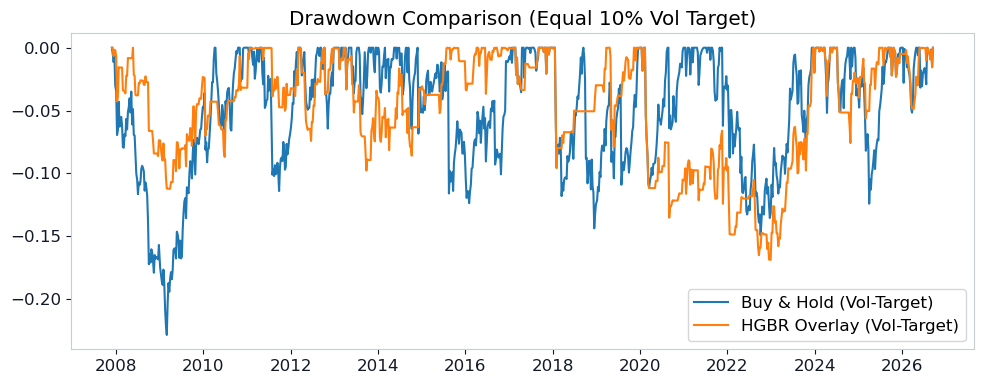

In [22]:
# ============================================================
# Compare Drawdowns:
# Overlay (Vol-Target) vs Buy & Hold (Vol-Targeted to same 10%)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_VOL = 0.10
ROLL_VOL = 20
STEP = 5
TC_BPS = 0.0   # no transaction cost for buy & hold baseline

# ------------------------------------------------------------
# 1) Build Buy & Hold 5-day bucket returns
# ------------------------------------------------------------
# Use same decision dates as HGBR overlay for clean alignment
hgb_overlay = curves_vt["HGBR"]
dec_idx = hgb_overlay.index

# annualized daily realized vol at each decision date (see ANN_VOL)
ann_vol = ANN_VOL.reindex(dec_idx)

# Vol-target weight
lev_bh = (TARGET_VOL / ann_vol).clip(upper=2.0).fillna(0.0)

# 5-day forward returns (aligned)
ret5 = y.loc[dec_idx]

# Apply leverage
ret5_vt_bh = lev_bh * ret5

eq_vt_bh = (1 + ret5_vt_bh).cumprod()

# ------------------------------------------------------------
# 2) Compute drawdowns
# ------------------------------------------------------------
def drawdown(series):
    peak = series.cummax()
    return series / peak - 1.0

dd_bh = drawdown(eq_vt_bh)
dd_overlay = drawdown(hgb_overlay["eq_vt"])

# ------------------------------------------------------------
# 3) Stats
# ------------------------------------------------------------
def stats(eq, dd):
    total_return = eq.iloc[-1] - 1
    max_dd = dd.min()
    mean_r = eq.pct_change().mean()
    vol_r = eq.pct_change().std()
    sharpe = (mean_r / vol_r) * np.sqrt(252/STEP)
    return total_return, max_dd, sharpe

bh_total, bh_mdd, bh_sharpe = stats(eq_vt_bh, dd_bh)
ov_total, ov_mdd, ov_sharpe = stats(hgb_overlay["eq_vt"], dd_overlay)

print("=== Vol-Target Comparison (10% target) ===")
print(f"Buy & Hold  - Total: {bh_total:.3f} | MaxDD: {bh_mdd:.3f} | Sharpe: {bh_sharpe:.3f}")
print(f"HGBR Overlay- Total: {ov_total:.3f} | MaxDD: {ov_mdd:.3f} | Sharpe: {ov_sharpe:.3f}")

# ------------------------------------------------------------
# 4) Plot drawdowns
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(dd_bh.index, dd_bh, label="Buy & Hold (Vol-Target)")
plt.plot(dd_overlay.index, dd_overlay, label="HGBR Overlay (Vol-Target)")
plt.title("Drawdown Comparison (Equal 10% Vol Target)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Institutional Stress Tests
# - Turnover
# - TC sensitivity (10 bps)
# - Target vol sensitivity (8% vs 10%)
# - Last 5-year performance
# ============================================================

import numpy as np
import pandas as pd

TARGET_VOL_BASE = 0.10
TARGET_VOL_LOW  = 0.08
ROLL_VOL = 20
STEP = 5

hgb_overlay = curves_vt["HGBR"].copy()
spy_px = df["SPY"].loc[hgb_overlay.index]
ret5 = y.loc[hgb_overlay.index]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def compute_stats(eq, ret, step=5):
    total = eq.iloc[-1] - 1
    peak = eq.cummax()
    dd = eq / peak - 1
    max_dd = dd.min()
    mean_r = ret.mean()
    vol_r = ret.std()
    sharpe = (mean_r / vol_r) * np.sqrt(252/step)
    return total, max_dd, sharpe

def vol_target_equity(target_vol, tc_bps):
    ann_vol = ANN_VOL.reindex(hgb_overlay.index)   # daily realized vol

    lev = (target_vol / ann_vol).clip(upper=2.0).fillna(0.0)
    w = hgb_overlay["pos"] * lev

    turn = w.diff().abs().fillna(w.iloc[0])
    tc = (tc_bps / 10000.0) * turn

    ret_net = w * ret5 - tc
    eq = (1 + ret_net).cumprod()

    return eq, ret_net, turn.mean()

# ------------------------------------------------------------
# 1️⃣ Turnover (avg weight change per 5d period)
# ------------------------------------------------------------
turnover = hgb_overlay["pos"].diff().abs().fillna(0).mean()

# ------------------------------------------------------------
# 2️⃣ TC sensitivity (10 bps)
# ------------------------------------------------------------
eq_10bps, ret_10bps, _ = vol_target_equity(TARGET_VOL_BASE, tc_bps=10)
tot_10bps, dd_10bps, sharpe_10bps = compute_stats(eq_10bps, ret_10bps)

# ------------------------------------------------------------
# 3️⃣ Target vol sensitivity (8%)
# ------------------------------------------------------------
eq_8vol, ret_8vol, _ = vol_target_equity(TARGET_VOL_LOW, tc_bps=5)
tot_8vol, dd_8vol, sharpe_8vol = compute_stats(eq_8vol, ret_8vol)

# ------------------------------------------------------------
# 4️⃣ Last 5 Years Only
# ------------------------------------------------------------
cutoff = eq_8vol.index.max() - pd.DateOffset(years=5)
mask_5y = eq_8vol.index >= cutoff

eq_5y = eq_8vol.loc[mask_5y]
ret_5y = ret_8vol.loc[mask_5y]

tot_5y, dd_5y, sharpe_5y = compute_stats(eq_5y, ret_5y)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("===== Institutional Risk Diagnostics =====\n")

print(f"Turnover (avg position change per 5d period): {turnover:.3f}")

print("\n--- TC = 10 bps (10% vol target) ---")
print(f"Total Return: {tot_10bps:.3f}")
print(f"Max Drawdown: {dd_10bps:.3f}")
print(f"Sharpe:       {sharpe_10bps:.3f}")

print("\n--- Target Vol = 8% (5 bps TC) ---")
print(f"Total Return: {tot_8vol:.3f}")
print(f"Max Drawdown: {dd_8vol:.3f}")
print(f"Sharpe:       {sharpe_8vol:.3f}")

print("\n--- Last 5 Years (8% vol target) ---")
print(f"Total Return: {tot_5y:.3f}")
print(f"Max Drawdown: {dd_5y:.3f}")
print(f"Sharpe:       {sharpe_5y:.3f}")

===== Institutional Risk Diagnostics =====

Turnover (avg position change per 5d period): 0.357

--- TC = 10 bps (10% vol target) ---
Total Return: 1.214
Max Drawdown: -0.186
Sharpe:       0.537

--- Target Vol = 8% (5 bps TC) ---
Total Return: 1.167
Max Drawdown: -0.136
Sharpe:       0.635

--- Last 5 Years (8% vol target) ---
Total Return: 1.167
Max Drawdown: -0.088
Sharpe:       0.998


In [24]:
# ============================================================
# FINAL PROFESSIONAL PERFORMANCE SUMMARY TABLE
# ============================================================

import numpy as np
import pandas as pd

STEP = 5

# Use existing objects
hgb_vt_10 = curves_vt["HGBR"]["eq_vt"]
hgb_ret_10 = curves_vt["HGBR"]["ret5_net_vt"]

# Recompute 8% vol-target
TARGET_VOL_8 = 0.08
ROLL_VOL = 20
spy_px = df["SPY"].loc[hgb_vt_10.index]
ret5 = y.loc[hgb_vt_10.index]

ann_vol = ANN_VOL.reindex(hgb_vt_10.index)   # daily realized vol
lev_8 = (TARGET_VOL_8 / ann_vol).clip(upper=2.0).fillna(0.0)
w_8 = curves_vt["HGBR"]["pos"] * lev_8
ret8 = w_8 * ret5
eq8 = (1 + ret8).cumprod()

# Buy & Hold 10% vol-target
TARGET_VOL_10 = 0.10
lev_bh = (TARGET_VOL_10 / ann_vol).clip(upper=2.0).fillna(0.0)
ret_bh = lev_bh * ret5
eq_bh = (1 + ret_bh).cumprod()

def perf_stats(eq, ret):
    total_return = eq.iloc[-1] - 1
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (eq.iloc[-1])**(1/years) - 1
    
    vol = ret.std() * np.sqrt(252/STEP)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252/STEP)
    
    downside = ret[ret < 0]
    sortino = (ret.mean() / downside.std()) * np.sqrt(252/STEP) if len(downside)>0 else np.nan
    
    peak = eq.cummax()
    dd = eq / peak - 1
    max_dd = dd.min()
    
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan
    
    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar
    }

summary = pd.DataFrame({
    "Buy & Hold (10% VT)": perf_stats(eq_bh, ret_bh),
    "HGBR Overlay (10% VT)": perf_stats(hgb_vt_10, hgb_ret_10),
    "HGBR Overlay (8% VT)": perf_stats(eq8, ret8)
}).T

# Add exposure + turnover
summary["Avg Exposure"] = [
    lev_bh.mean(),
    curves_vt["HGBR"]["w"].mean(),
    w_8.mean()
]

summary["Turnover"] = [
    0.0,
    curves_vt["HGBR"]["w"].diff().abs().mean(),
    w_8.diff().abs().mean()
]

summary = summary.round(4)

print("\n===== FINAL PERFORMANCE SUMMARY =====\n")
display(summary)


===== FINAL PERFORMANCE SUMMARY =====



,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Avg Exposure,Turnover
Buy & Hold (10% VT),3.8776,0.0880,0.1126,0.7825,0.9394,-0.2286,0.3849,0.8314,0.0000
HGBR Overlay (10% VT),1.5903,0.0519,0.0827,0.6348,0.6783,-0.1688,0.3078,0.4732,0.3219
HGBR Overlay (8% VT),1.4589,0.0490,0.0663,0.7332,0.7059,-0.1214,0.4038,0.3801,0.2588


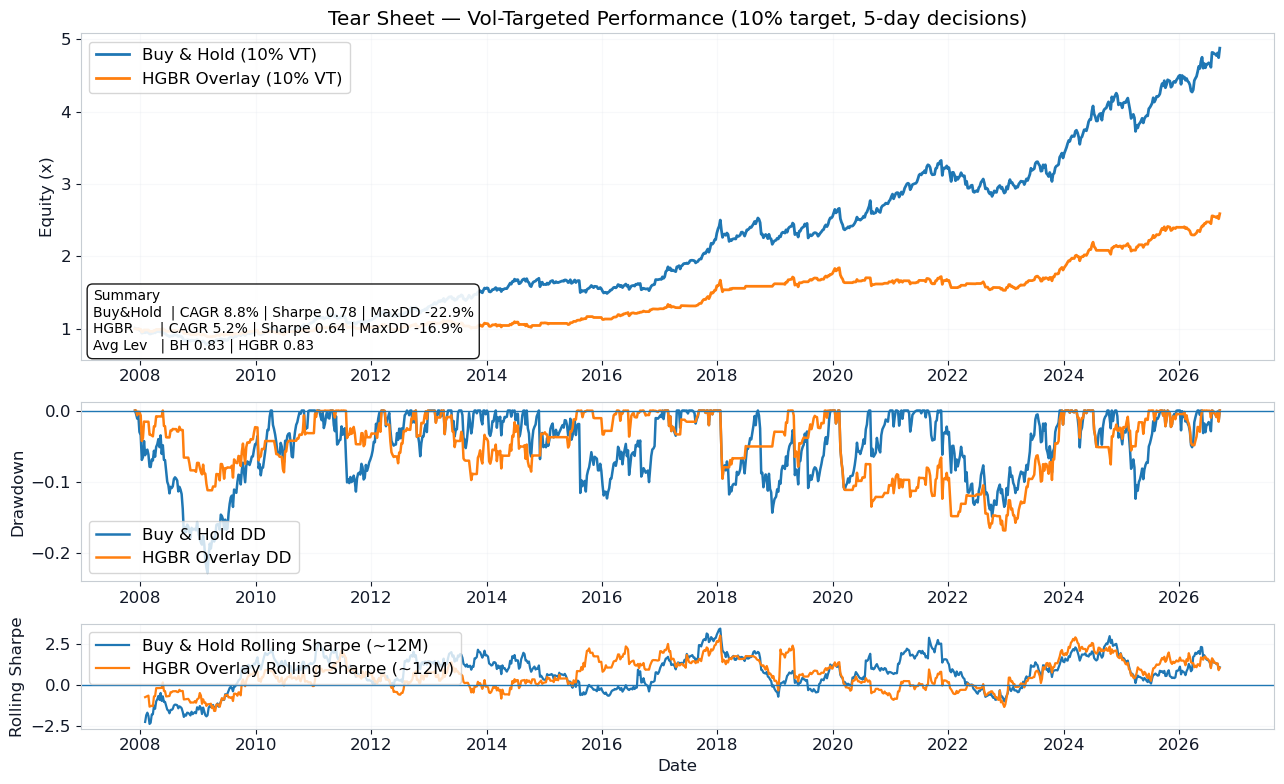


=== Tear Sheet Summary Table ===
                       Total Return    CAGR  Ann Vol  Sharpe  Max DD  Avg Leverage
Buy&Hold (10% VT)            3.8776  0.0880   0.1126  0.7829 -0.2286        0.8314
HGBR Overlay (10% VT)        1.5903  0.0519   0.0827  0.6352 -0.1688        0.8314


In [25]:
# ============================================================
# Professional Tear Sheet (Matplotlib) — Equity + Drawdown + Rolling Sharpe
# Compares: Buy & Hold (Vol-Target 10%) vs HGBR Overlay (Vol-Target 10%)
# Assumes you already have: curves_vt["HGBR"], df["SPY"], y
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP = 5
ROLL_VOL = 20
TARGET_VOL = 0.10
MAX_LEV = 2.0

# --- pull aligned index (decision dates) from your HGBR vol-target run ---
vt = curves_vt["HGBR"].copy()
idx = vt.index

# --- returns & equity for HGBR vol-target overlay (already computed) ---
eq_hgbr = vt["eq_vt"].astype(float)
r_hgbr  = vt["ret5_net_vt"].astype(float)

# --- build Buy & Hold vol-targeted to same 10% on same decision dates ---
ann_vol = ANN_VOL.reindex(idx)   # daily realized vol

lev_bh = (TARGET_VOL / ann_vol).clip(lower=0.0, upper=MAX_LEV).fillna(0.0)

ret5 = y.loc[idx].astype(float)
r_bh = (lev_bh * ret5).astype(float)
eq_bh = (1.0 + r_bh).cumprod()

# --- helpers ---
def drawdown(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def ann_sharpe(r: pd.Series, step=5) -> float:
    r = r.dropna()
    if r.std(ddof=0) == 0 or len(r) < 5:
        return np.nan
    return float((r.mean() / r.std(ddof=0)) * np.sqrt(252 / step))

def ann_volatility(r: pd.Series, step=5) -> float:
    r = r.dropna()
    return float(r.std(ddof=0) * np.sqrt(252 / step))

def cagr(eq: pd.Series) -> float:
    eq = eq.dropna()
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    return float(eq.iloc[-1] ** (1 / yrs) - 1) if yrs > 0 else np.nan

def max_dd(eq: pd.Series) -> float:
    return float(drawdown(eq).min())

def rolling_sharpe(r: pd.Series, window=52, step=5) -> pd.Series:
    # window ~ 52 decision points ≈ ~1 year in your 5-day cadence
    out = pd.Series(index=r.index, dtype=float)
    for i in range(len(r)):
        j0 = max(0, i - window + 1)
        rr = r.iloc[j0:i+1].dropna()
        if len(rr) < 10 or rr.std(ddof=0) == 0:
            out.iloc[i] = np.nan
        else:
            out.iloc[i] = (rr.mean() / rr.std(ddof=0)) * np.sqrt(252 / step)
    return out

# --- compute tear sheet series ---
dd_hgbr = drawdown(eq_hgbr)
dd_bh   = drawdown(eq_bh)

rollS_hgbr = rolling_sharpe(r_hgbr, window=52, step=STEP)
rollS_bh   = rolling_sharpe(r_bh,   window=52, step=STEP)

# --- stats box values ---
stats = pd.DataFrame({
    "Buy&Hold (10% VT)": {
        "Total Return": eq_bh.iloc[-1] - 1,
        "CAGR": cagr(eq_bh),
        "Ann Vol": ann_volatility(r_bh, STEP),
        "Sharpe": ann_sharpe(r_bh, STEP),
        "Max DD": max_dd(eq_bh),
        "Avg Leverage": float(lev_bh.mean()),
    },
    "HGBR Overlay (10% VT)": {
        "Total Return": eq_hgbr.iloc[-1] - 1,
        "CAGR": cagr(eq_hgbr),
        "Ann Vol": ann_volatility(r_hgbr, STEP),
        "Sharpe": ann_sharpe(r_hgbr, STEP),
        "Max DD": max_dd(eq_hgbr),
        "Avg Leverage": float(vt["lev"].mean()) if "lev" in vt.columns else np.nan,
    }
}).T

# --- Tear Sheet Figure ---
fig = plt.figure(figsize=(13, 8), facecolor="white")

# 1) Equity
ax1 = plt.subplot2grid((10, 1), (0, 0), rowspan=5)
ax1.plot(eq_bh.index, eq_bh.values, label="Buy & Hold (10% VT)", linewidth=2)
ax1.plot(eq_hgbr.index, eq_hgbr.values, label="HGBR Overlay (10% VT)", linewidth=2)
ax1.set_title("Tear Sheet — Vol-Targeted Performance (10% target, 5-day decisions)")
ax1.set_ylabel("Equity (x)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

# 2) Drawdown
ax2 = plt.subplot2grid((10, 1), (5, 0), rowspan=3, sharex=ax1)
ax2.plot(dd_bh.index, dd_bh.values, label="Buy & Hold DD", linewidth=1.8)
ax2.plot(dd_hgbr.index, dd_hgbr.values, label="HGBR Overlay DD", linewidth=1.8)
ax2.axhline(0, linewidth=1)
ax2.set_ylabel("Drawdown")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower left")

# 3) Rolling Sharpe
ax3 = plt.subplot2grid((10, 1), (8, 0), rowspan=2, sharex=ax1)
ax3.plot(rollS_bh.index, rollS_bh.values, label="Buy & Hold Rolling Sharpe (~12M)", linewidth=1.6)
ax3.plot(rollS_hgbr.index, rollS_hgbr.values, label="HGBR Overlay Rolling Sharpe (~12M)", linewidth=1.6)
ax3.axhline(0, linewidth=1)
ax3.set_ylabel("Rolling Sharpe")
ax3.set_xlabel("Date")
ax3.grid(True, alpha=0.3)
ax3.legend(loc="upper left")

# --- stats box on equity panel ---
def fmt_pct(x): 
    return f"{x*100:,.1f}%"
def fmt_num(x):
    return f"{x:,.2f}"

bh = stats.loc["Buy&Hold (10% VT)"]
hg = stats.loc["HGBR Overlay (10% VT)"]

textbox = (
    "Summary\n"
    f"Buy&Hold  | CAGR {fmt_pct(bh['CAGR'])} | Sharpe {fmt_num(bh['Sharpe'])} | MaxDD {fmt_pct(bh['Max DD'])}\n"
    f"HGBR      | CAGR {fmt_pct(hg['CAGR'])} | Sharpe {fmt_num(hg['Sharpe'])} | MaxDD {fmt_pct(hg['Max DD'])}\n"
    f"Avg Lev   | BH {fmt_num(bh['Avg Leverage'])} | HGBR {fmt_num(hg['Avg Leverage'])}"
)
ax1.text(
    0.01, 0.02, textbox,
    transform=ax1.transAxes,
    fontsize=10,
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

# Optional: print the table for copy/paste into slides
print("\n=== Tear Sheet Summary Table ===")
print(stats.round(4).to_string())

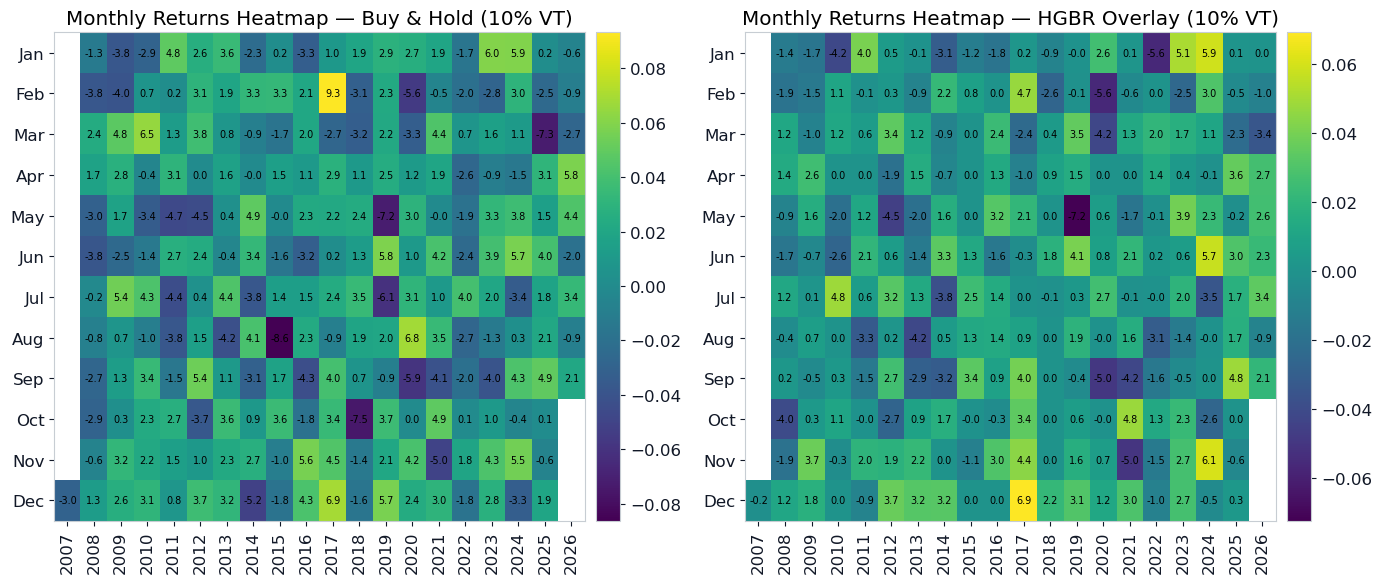

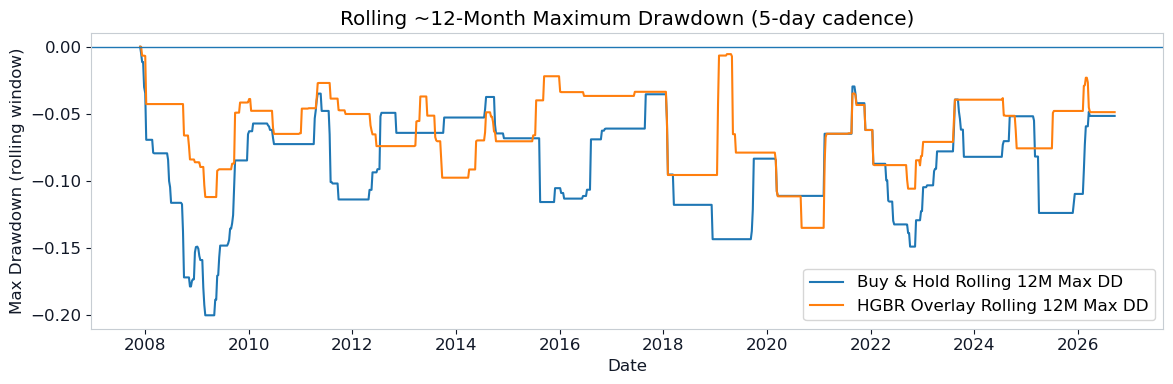

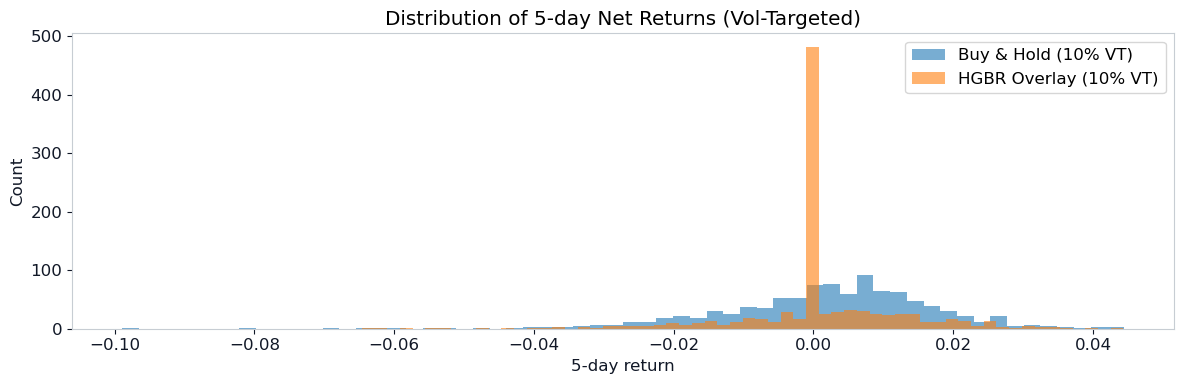


=== 5% Tail Risk (5-day returns) ===
Buy & Hold  | VaR(5%): -2.5025% | CVaR(5%): -3.9407%
HGBR Overlay| VaR(5%): -1.8987% | CVaR(5%): -3.0231%

=== Monthly Return Stats (from vol-targeted series) ===
           Buy & Hold HGBR Overlay
Mean          0.7488%      0.4482%
Std           3.1546%      2.2917%
% Positive   63.2743%     54.4248%
Worst        -8.6329%     -7.2436%
Best          9.3282%      6.9108%


In [26]:
# ============================================================
# FULL TEAR SHEET EXTENSIONS (ALL 3):
# 1) Monthly return heatmap
# 2) Rolling 12M max drawdown
# 3) Distribution of 5-day returns + VaR/CVaR
#
# Compares: Buy & Hold (Vol-Target 10%) vs HGBR Overlay (Vol-Target 10%)
# Assumes you already have: curves_vt["HGBR"], df["SPY"], y
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP = 5
ROLL_VOL = 20
TARGET_VOL = 0.10
MAX_LEV = 2.0

# -----------------------------
# Pull aligned decision index + series
# -----------------------------
vt = curves_vt["HGBR"].copy()
idx = vt.index

# HGBR vol-target overlay (already computed in your prior cell)
eq_hgbr = vt["eq_vt"].astype(float)
r_hgbr  = vt["ret5_net_vt"].astype(float)

# Buy & Hold vol-targeted to same 10% on same decision dates
ann_vol = ANN_VOL.reindex(idx)   # daily realized vol
lev_bh = (TARGET_VOL / ann_vol).clip(lower=0.0, upper=MAX_LEV).fillna(0.0)

ret5 = y.loc[idx].astype(float)
r_bh = (lev_bh * ret5).astype(float)
eq_bh = (1.0 + r_bh).cumprod()

# -----------------------------
# Helpers
# -----------------------------
def drawdown(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def rolling_max_dd(eq: pd.Series, window=52) -> pd.Series:
    # window ~ 52 decision points ≈ ~1 year for your 5-day cadence
    eq = eq.dropna()
    out = pd.Series(index=eq.index, dtype=float)
    for i in range(len(eq)):
        j0 = max(0, i - window + 1)
        sub = eq.iloc[j0:i+1]
        dd = drawdown(sub)
        out.iloc[i] = dd.min() if len(dd) else np.nan
    return out

def to_monthly_returns(ret5_series: pd.Series, step=5) -> pd.Series:
    """
    Convert 5-day net returns into monthly compounded returns:
    - Build 5-day equity -> resample end-of-month -> pct_change.
    """
    eq = (1.0 + ret5_series.fillna(0.0)).cumprod()
    eq_m = eq.resample("ME").last()
    return eq_m.pct_change().dropna()

def monthly_heatmap_data(monthly_ret: pd.Series) -> pd.DataFrame:
    """
    Returns a 12 x N table (months x years) for heatmap.
    """
    dfm = monthly_ret.to_frame("r")
    dfm["Year"] = dfm.index.year
    dfm["Month"] = dfm.index.month
    pivot = dfm.pivot(index="Month", columns="Year", values="r")
    # Ensure all months 1..12 present
    pivot = pivot.reindex(index=range(1,13))
    return pivot

def plot_monthly_heatmap(ax, pivot: pd.DataFrame, title: str):
    """
    Matplotlib-only heatmap (no seaborn). Annotates each cell with %.
    Colors are automatic (no manual colormap specification).
    """
    data = pivot.values
    im = ax.imshow(data, aspect="auto")
    ax.set_title(title)
    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([str(y) for y in pivot.columns], rotation=90)
    # annotate
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v*100:.1f}", ha="center", va="center", fontsize=7)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

def var_cvar(x: pd.Series, alpha=0.05):
    """
    VaR/CVaR for returns (loss is negative). Returns (VaR, CVaR).
    VaR: alpha-quantile (e.g., 5% worst)
    CVaR: mean of returns <= VaR
    """
    x = x.dropna().astype(float)
    if len(x) == 0:
        return np.nan, np.nan
    v = float(x.quantile(alpha))
    tail = x[x <= v]
    c = float(tail.mean()) if len(tail) else np.nan
    return v, c

# -----------------------------
# 1) Monthly return heatmaps
# -----------------------------
mret_bh = to_monthly_returns(r_bh, step=STEP)
mret_hg = to_monthly_returns(r_hgbr, step=STEP)

hm_bh = monthly_heatmap_data(mret_bh)
hm_hg = monthly_heatmap_data(mret_hg)

# -----------------------------
# 2) Rolling 12M max drawdown
# -----------------------------
roll_mdd_bh = rolling_max_dd(eq_bh, window=52)
roll_mdd_hg = rolling_max_dd(eq_hgbr, window=52)

# -----------------------------
# 3) 5-day return distribution + VaR/CVaR
# -----------------------------
v_bh, c_bh = var_cvar(r_bh, alpha=0.05)
v_hg, c_hg = var_cvar(r_hgbr, alpha=0.05)

# -----------------------------
# PLOTS (3 figures)
# -----------------------------

# --- Figure A: Monthly return heatmaps (side-by-side) ---
fig = plt.figure(figsize=(14, 6))
ax1 = plt.subplot(1, 2, 1)
plot_monthly_heatmap(ax1, hm_bh, "Monthly Returns Heatmap — Buy & Hold (10% VT)")
ax2 = plt.subplot(1, 2, 2)
plot_monthly_heatmap(ax2, hm_hg, "Monthly Returns Heatmap — HGBR Overlay (10% VT)")
plt.tight_layout()
plt.show()

# --- Figure B: Rolling 12M Max Drawdown ---
plt.figure(figsize=(12, 4))
plt.plot(roll_mdd_bh.index, roll_mdd_bh.values, label="Buy & Hold Rolling 12M Max DD")
plt.plot(roll_mdd_hg.index, roll_mdd_hg.values, label="HGBR Overlay Rolling 12M Max DD")
plt.axhline(0, linewidth=1)
plt.title("Rolling ~12-Month Maximum Drawdown (5-day cadence)")
plt.ylabel("Max Drawdown (rolling window)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure C: Distribution of 5-day returns + VaR/CVaR ---
plt.figure(figsize=(12, 4))
plt.hist(r_bh.dropna().values, bins=60, alpha=0.6, label="Buy & Hold (10% VT)")
plt.hist(r_hgbr.dropna().values, bins=60, alpha=0.6, label="HGBR Overlay (10% VT)")
plt.title("Distribution of 5-day Net Returns (Vol-Targeted)")
plt.xlabel("5-day return")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Print VaR/CVaR summary (5% tail)
print("\n=== 5% Tail Risk (5-day returns) ===")
print(f"Buy & Hold  | VaR(5%): {v_bh:+.4%} | CVaR(5%): {c_bh:+.4%}")
print(f"HGBR Overlay| VaR(5%): {v_hg:+.4%} | CVaR(5%): {c_hg:+.4%}")

# Optional: quick monthly stats for slide bullets
monthly_summary = pd.DataFrame({
    "Buy&Hold_monthly": mret_bh,
    "HGBR_monthly": mret_hg
}).dropna()

def monthly_stats(s: pd.Series):
    return pd.Series({
        "Mean": s.mean(),
        "Std": s.std(),
        "% Positive": (s > 0).mean(),
        "Worst": s.min(),
        "Best": s.max(),
    })

print("\n=== Monthly Return Stats (from vol-targeted series) ===")
print(pd.concat([
    monthly_stats(monthly_summary["Buy&Hold_monthly"]).rename("Buy & Hold"),
    monthly_stats(monthly_summary["HGBR_monthly"]).rename("HGBR Overlay"),
], axis=1).map(lambda x: f"{x:.4%}" if isinstance(x, (float, np.floating)) else x))

In [27]:
import tensorflow as tf
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

tf.get_logger().setLevel("ERROR")


## Optional: LSTM walk-forward (not run)
The cell below is kept as a raw cell so it doesn't run by default. To run it, change the cell type to **Code**. It needs TensorFlow and takes roughly 80 minutes on a CPU.

Note: this experimental cell uses all features and does not include the purge gap or per-window feature selection used by the main models.
